# Phase 4 — Scorecard ASB workbench (PD Ins + PD Css)

Tune bins and prescreen, fit models, review bin stability on shortlisted variables, then build scorecard.

Work one product at a time (`PRODUCT`). Freeze bins before §3.

Each helper is **one cell** with a `checkpoint` block at the bottom. Run top-to-bottom; checkpoints use pipeline data from above cells only.

## Checklist
- [ ] §0 `SCORECARD_PARAMS` + `PRODUCT`
- [ ] §1 load + partition + slice
- [ ] §2 bin tuning loop until prescreen gate passes
- [ ] §3.1–3.3 RFE + Model_list
- [ ] §3.4–3.5 diagnose + subModel_list
- [ ] §3.5b BR review (subModel_list vars only)
- [ ] §3.6–3.8 pick winner + model_package
- [ ] §4 scorecard + calibration
- [ ] §5 Gini over time
- [ ] §6 save parquet artifacts
- [ ] Repeat for `css`

| Prof reference | Notebook |
|----------------|----------|
| Big_scorecard.xlsx | `big_scorecard` + plots |
| Gini_vars.xlsx | `gini_vars` |
| Variable_report.xlsx | `variable_report` + `plot_bin_stability` |
| Model_report.xlsx | `model_report` + `display_model_report` |



## §0 — Setup

In [1]:
import json
import pickle
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", None)

assert Path("../data/04_feature/abt_app.parquet").exists()
assert Path("../data/04_feature/decisions.parquet").exists()

PRODUCT = "css"

SCORECARD_PARAMS = {
    "target": "default12",
    "time_col": "period",
    "id_col": "aid",
    "train_end_period": "198512",
    "valid_start_period": "198601",
    "symbol_missing": "Missing",
    "symbol_other": "<OTHERS>",
    "woe_epsilon": 1e-4,
    "tree_random_state": 1234,
    "factor": 20 / np.log(2),
    "offset": 600 - (20 / np.log(2)) * np.log(50),
    "category_order": False,
    "candidate": {"prefixes": ["app", "act"]},
    "binning": {
        "ncategories_int": 3,
        "minimum_share_int": 0.2,
        "ncategories_nom": 3,
        "rare_threshold": 0.05,
    },
    "prescreen": {
        "iv_min": 0.02,
        "gini_min": 0.02,
        "psi_max": 0.2,
        "psi_tar_max": 0.1,
        "delta_gini_max": 0.2,
        "ar_diff_max": 0.20,
    },
    "stability": {
        "min_bin_n_period": 10,
        "min_bin_n_total": 30,
        "max_bad_rate_swing": 0.15,
        "min_periods_for_stability": 6,
        "max_plots": None,
        "min_static_br_gap": 0.02,      # 2 percentage points
        "min_period_br_gap": 0.02,      # for time-gap stability checks
        "min_periods_for_gap": 6,
    },
    "selection": {
        "number_vars": 12,
        "number_features": 5,
        "pvalue_max": 0.01,
        "vif_max": 4.0,
        "sort_metric": "gini_valid",
        "max_features": 12,
        "epsilon": 1e-4,
    },
}

# Flat aliases for helpers that read flat keys.
SCORECARD_PARAMS.update(SCORECARD_PARAMS["binning"])
SCORECARD_PARAMS.update(SCORECARD_PARAMS["prescreen"])
SCORECARD_PARAMS.update(SCORECARD_PARAMS["stability"])
SCORECARD_PARAMS.update(SCORECARD_PARAMS["selection"])


## §1 — Data prep (run once)

**§1 cell run order** (top → bottom):
1. `prepare_target`
2. `load_and_prepare_abt`
3. **Load ABT** → creates `df_model`, `df_accepted`
4. `partition_abt` → checkpoint uses `df_accepted`
5. `slice_product`
6. `get_candidate_features`
7. **Partition + product slices** → `df_train`, `train_product`, `valid_product`


In [2]:
# Columns excluded from binning / features
LEAKAGE_COLS = [
    "default3", "default6", "default12", "decision", "decline_reason",
    "act_cus_active",
]
ID_COLS = ["cid", "aid", "period", "product"]


In [3]:
def prepare_target(df, target="default12"):
	"""Convert target to binary"""
	out = df.copy()
	out[target] = out[target].map({".i": 0, ".d": 0, 0: 0, 1: 1})
	out = out.dropna(subset=[target])
	out[target] = out[target].astype(int)
	return out

# --- checkpoint: prepare_target ---
_raw = pd.DataFrame({"default12": [".i", ".d", 0, 1, None]})
_out = prepare_target(_raw, target="default12")
print("checkpoint prepare_target:", _out["default12"].dropna().tolist())


checkpoint prepare_target: [0, 0, 0, 1]


In [4]:
def load_and_prepare_abt(abt_path, decisions_path):
	"""Load and prepare application data"""
	abt = pd.read_parquet(abt_path)
	decisions = pd.read_parquet(decisions_path)
	merged = abt.merge(
		decisions[["aid", "decision", "decline_reason"]],
		on="aid",
		how="left",
	)
	return prepare_target(merged)

# --- checkpoint: load_and_prepare_abt ---
df_model = load_and_prepare_abt(
    "../data/04_feature/abt_app.parquet",
    "../data/04_feature/decisions.parquet",
)
print(f"checkpoint load_and_prepare_abt: rows={len(df_model)} bad_rate={df_model['default12'].mean():.2%}")


checkpoint load_and_prepare_abt: rows=44602 bad_rate=41.04%


In [5]:
# §1 — Load ABT (run before partition/slice checkpoints)
df_model = load_and_prepare_abt(
    "../data/04_feature/abt_app.parquet",
    "../data/04_feature/decisions.parquet",
)
assert df_model["aid"].is_unique
print("rows:", len(df_model), "bad rate:", f"{df_model['default12'].mean():.2%}")
df_accepted = df_model[df_model["decision"] == "A"].copy()
print("accepted:", len(df_accepted))


rows: 44602 bad rate: 41.04%
accepted: 44602


In [6]:
def partition_abt(df, train_end, valid_start, time_col="period"):
	"""Filter data into train and valid sets based on period"""
	work = df.copy()
	df_train = work[work[time_col] <= train_end]
	df_valid = work[work[time_col] >= valid_start]
	return df_train, df_valid

# --- checkpoint: partition_abt ---
_acc = df_accepted
_tr, _va = partition_abt(
    _acc,
    SCORECARD_PARAMS["train_end_period"],
    SCORECARD_PARAMS["valid_start_period"],
    time_col=SCORECARD_PARAMS["time_col"],
)
print(f"checkpoint partition_abt: train={len(_tr)} valid={len(_va)}")
print(_tr[SCORECARD_PARAMS["time_col"]].min(), "→", _tr[SCORECARD_PARAMS["time_col"]].max())


checkpoint partition_abt: train=37775 valid=6827
197501 → 198512


In [7]:
def slice_product(df, product, decision="A"):
	"""Slice datasets based on product and decision"""
	return df[(df["product"] == product) & (df["decision"] == decision)].copy()

# --- checkpoint: slice_product ---
_base = _tr
_sl = slice_product(_base, PRODUCT)
print(f"checkpoint slice_product: n={len(_sl)} bad_rate={_sl['default12'].mean():.2%}")
display(_sl.head())


checkpoint slice_product: n=18932 bad_rate=69.49%


,cid,aid,product,period,act_age,act_cc,act_loaninc,app_income,app_loan_amount,app_n_installments,app_number_of_children,app_spendings,app_installment,app_char_branch,app_char_gender,app_char_job_code,app_char_marital_status,app_char_city,app_char_home_status,app_char_cars,act_call_cc,act_cins_n_loan,act_ccss_n_loan,act_call_n_loan,ags3_Mean_CMaxI_Days,agr3_Mean_CMaxI_Days,ags3_Max_CMaxI_Days,agr3_Max_CMaxI_Days,ags3_Min_CMaxI_Days,agr3_Min_CMaxI_Days,ags6_Mean_CMaxI_Days,agr6_Mean_CMaxI_Days,ags6_Max_CMaxI_Days,agr6_Max_CMaxI_Days,ags6_Min_CMaxI_Days,agr6_Min_CMaxI_Days,ags9_Mean_CMaxI_Days,agr9_Mean_CMaxI_Days,ags9_Max_CMaxI_Days,agr9_Max_CMaxI_Days,ags9_Min_CMaxI_Days,agr9_Min_CMaxI_Days,ags12_Mean_CMaxI_Days,agr12_Mean_CMaxI_Days,ags12_Max_CMaxI_Days,agr12_Max_CMaxI_Days,ags12_Min_CMaxI_Days,agr12_Min_CMaxI_Days,ags3_Mean_CMaxI_Due,agr3_Mean_CMaxI_Due,ags3_Max_CMaxI_Due,agr3_Max_CMaxI_Due,ags3_Min_CMaxI_Due,agr3_Min_CMaxI_Due,ags6_Mean_CMaxI_Due,agr6_Mean_CMaxI_Due,ags6_Max_CMaxI_Due,agr6_Max_CMaxI_Due,ags6_Min_CMaxI_Due,agr6_Min_CMaxI_Due,ags9_Mean_CMaxI_Due,agr9_Mean_CMaxI_Due,ags9_Max_CMaxI_Due,agr9_Max_CMaxI_Due,ags9_Min_CMaxI_Due,agr9_Min_CMaxI_Due,ags12_Mean_CMaxI_Due,agr12_Mean_CMaxI_Due,ags12_Max_CMaxI_Due,agr12_Max_CMaxI_Due,ags12_Min_CMaxI_Due,agr12_Min_CMaxI_Due,ags3_Mean_CMaxC_Days,agr3_Mean_CMaxC_Days,ags3_Max_CMaxC_Days,agr3_Max_CMaxC_Days,ags3_Min_CMaxC_Days,agr3_Min_CMaxC_Days,ags6_Mean_CMaxC_Days,agr6_Mean_CMaxC_Days,ags6_Max_CMaxC_Days,agr6_Max_CMaxC_Days,ags6_Min_CMaxC_Days,agr6_Min_CMaxC_Days,ags9_Mean_CMaxC_Days,agr9_Mean_CMaxC_Days,ags9_Max_CMaxC_Days,agr9_Max_CMaxC_Days,ags9_Min_CMaxC_Days,agr9_Min_CMaxC_Days,ags12_Mean_CMaxC_Days,agr12_Mean_CMaxC_Days,ags12_Max_CMaxC_Days,agr12_Max_CMaxC_Days,ags12_Min_CMaxC_Days,agr12_Min_CMaxC_Days,ags3_Mean_CMaxC_Due,agr3_Mean_CMaxC_Due,ags3_Max_CMaxC_Due,agr3_Max_CMaxC_Due,ags3_Min_CMaxC_Due,agr3_Min_CMaxC_Due,ags6_Mean_CMaxC_Due,agr6_Mean_CMaxC_Due,ags6_Max_CMaxC_Due,agr6_Max_CMaxC_Due,ags6_Min_CMaxC_Due,agr6_Min_CMaxC_Due,ags9_Mean_CMaxC_Due,agr9_Mean_CMaxC_Due,ags9_Max_CMaxC_Due,agr9_Max_CMaxC_Due,ags9_Min_CMaxC_Due,agr9_Min_CMaxC_Due,ags12_Mean_CMaxC_Due,agr12_Mean_CMaxC_Due,ags12_Max_CMaxC_Due,agr12_Max_CMaxC_Due,ags12_Min_CMaxC_Due,agr12_Min_CMaxC_Due,ags3_Mean_CMaxA_Days,agr3_Mean_CMaxA_Days,ags3_Max_CMaxA_Days,agr3_Max_CMaxA_Days,ags3_Min_CMaxA_Days,agr3_Min_CMaxA_Days,ags6_Mean_CMaxA_Days,agr6_Mean_CMaxA_Days,ags6_Max_CMaxA_Days,agr6_Max_CMaxA_Days,ags6_Min_CMaxA_Days,agr6_Min_CMaxA_Days,ags9_Mean_CMaxA_Days,agr9_Mean_CMaxA_Days,ags9_Max_CMaxA_Days,agr9_Max_CMaxA_Days,ags9_Min_CMaxA_Days,agr9_Min_CMaxA_Days,ags12_Mean_CMaxA_Days,agr12_Mean_CMaxA_Days,ags12_Max_CMaxA_Days,agr12_Max_CMaxA_Days,ags12_Min_CMaxA_Days,agr12_Min_CMaxA_Days,ags3_Mean_CMaxA_Due,agr3_Mean_CMaxA_Due,ags3_Max_CMaxA_Due,agr3_Max_CMaxA_Due,ags3_Min_CMaxA_Due,agr3_Min_CMaxA_Due,ags6_Mean_CMaxA_Due,agr6_Mean_CMaxA_Due,ags6_Max_CMaxA_Due,agr6_Max_CMaxA_Due,ags6_Min_CMaxA_Due,agr6_Min_CMaxA_Due,ags9_Mean_CMaxA_Due,agr9_Mean_CMaxA_Due,ags9_Max_CMaxA_Due,agr9_Max_CMaxA_Due,ags9_Min_CMaxA_Due,agr9_Min_CMaxA_Due,ags12_Mean_CMaxA_Due,agr12_Mean_CMaxA_Due,ags12_Max_CMaxA_Due,agr12_Max_CMaxA_Due,ags12_Min_CMaxA_Due,agr12_Min_CMaxA_Due,act3_n_arrears,act3_n_arrears_days,act3_n_good_days,act6_n_arrears,act6_n_arrears_days,act6_n_good_days,act9_n_arrears,act9_n_arrears_days,act9_n_good_days,act12_n_arrears,act12_n_arrears_days,act12_n_good_days,act_cins_n_loans_act,act_cins_maxdue,act_cins_min_pninst,act_cins_min_lninst,act_cins_utl,act_cins_dueutl,act_cins_cc,act_cins_seniority,act_cins_min_seniority,act_cins_n_loans_hist,act_cins_n_statC,act_cins_n_statB,act_ccss_n_loans_act,act_ccss_maxdue,act_ccss_min_pninst,act_ccss_min_lninst,act_ccss_utl,act_ccss_dueutl,act_ccss_cc,act_ccss_seniority,act_ccss_min_seniority,act_ccss_n_loans_hist,act_ccss_n_statC,act_ccss_n_statB,act_cus_active,default3,default6,default12,decision,decline_reason
0,0000000625,css1975010100063,css,197501,55.0,0.629712,1.583782,3

In [8]:
def get_candidate_features(df, product, params):
	"""Get candidate features, drop leakage columns and ID columns. Return numeric and nominal features."""
	work = slice_product(df, product)
	work = work.dropna(subset=["decision", "decline_reason"])
	prefixes = params.get("candidate", {}).get("prefixes", [])
	if prefixes:
		work = work[[c for c in work.columns if c[:3].lower() in prefixes or c in ID_COLS + LEAKAGE_COLS]]
	drop_cols = [c for c in LEAKAGE_COLS + ID_COLS if c in work.columns]
	work = work.drop(columns=drop_cols)
	numeric = [
		c for c in work.columns
		if pd.api.types.is_numeric_dtype(work[c]) and not pd.api.types.is_bool_dtype(work[c])
	]
	nominal = [
		c for c in work.columns
		if c not in numeric
		and (
			pd.api.types.is_object_dtype(work[c])
			or pd.api.types.is_string_dtype(work[c])
			or isinstance(work[c].dtype, pd.CategoricalDtype)
			or pd.api.types.is_bool_dtype(work[c])
		)
	]
	return {"numeric": numeric, "nominal": nominal, "all": numeric + nominal}

# --- checkpoint: get_candidate_features ---
cand = get_candidate_features(df_model, PRODUCT, SCORECARD_PARAMS)
print(f"checkpoint get_candidate_features: numeric={len(cand['numeric'])} nominal={len(cand['nominal'])} all={len(cand['all'])}")
print("all features:", cand["all"][:5])
print("numeric features:", cand["numeric"][:5])
print("nominal features:", cand["nominal"][:5])


checkpoint get_candidate_features: numeric=49 nominal=7 all=56
all features: ['act_age', 'act_cc', 'act_loaninc', 'app_income', 'app_loan_amount']
numeric features: ['act_age', 'act_cc', 'act_loaninc', 'app_income', 'app_loan_amount']
nominal features: ['app_char_branch', 'app_char_gender', 'app_char_job_code', 'app_char_marital_status', 'app_char_city']


In [9]:
# §1 — Partition + product slices (after all §1 helpers defined)
print(df_model.groupby(["product", "decision"])["default12"].mean())
print(f"{PRODUCT} candidates:", len(cand["all"]))
print("candidate prefixes:", SCORECARD_PARAMS["candidate"]["prefixes"])

blocked_prefixes = ("agr", "ags")
blocked_found = [f for f in cand["all"] if f.startswith(blocked_prefixes)]
print("agr/ags present:", len(blocked_found))
print("act9_n_arrears in candidates:", "act9_n_arrears" in cand["all"])

df_train, df_valid = partition_abt(
    df_accepted,
    SCORECARD_PARAMS["train_end_period"],
    SCORECARD_PARAMS["valid_start_period"],
    time_col=SCORECARD_PARAMS["time_col"],
)
train_product = slice_product(df_train, PRODUCT)
valid_product = slice_product(df_valid, PRODUCT)

for name, d in [("train", train_product), ("valid", valid_product)]:
    print(
        name,
        d["period"].min(), "→", d["period"].max(),
        "bad_rate", f"{d['default12'].mean():.2%}",
        "n", len(d),
    )


product  decision
css      A           0.683755
ins      A           0.137648
Name: default12, dtype: float64
css candidates: 56
candidate prefixes: ['app', 'act']
agr/ags present: 0
act9_n_arrears in candidates: True
train 197501 → 198512 bad_rate 69.49% n 18932
valid 198601 → 198712 bad_rate 62.09% n 3345


## §2 — Bin tuning loop (repeat until prescreen gate passes)

Re-run §2 exec + gate after tuning `ncategories_int`, `minimum_share_int`, `ncategories_nom`, `psi_max`.
Gate checks prescreen count and thin bins only — BR-over-time stability runs in §3.5b.


### §2a — Binning helpers

In [10]:
def _bin_params(params):
		"""Get bin parameters"""
		return {
				"other_label": params.get("symbol_other", "<OTHERS>"),
				"missing_label": params.get("symbol_missing", "Missing"),
				"max_bins": params.get("ncategories_int", 4),
				"min_bin_size": params.get("minimum_share_int", 0.03),
				"tree_random_state": params.get("tree_random_state", 1234),
				"rare_threshold": params.get("rare_threshold", params.get("minimum_share_unique", 0.03)),
				"max_groups": params.get("ncategories_nom", 4),
				"nominal_int_threshold": params.get("nominal_int_threshold", 10),
		}

# --- checkpoint: _bin_params ---
_bp = _bin_params(SCORECARD_PARAMS)
print("checkpoint _bin_params:", _bp)


checkpoint _bin_params: {'other_label': '<OTHERS>', 'missing_label': 'Missing', 'max_bins': 3, 'min_bin_size': 0.2, 'tree_random_state': 1234, 'rare_threshold': 0.05, 'max_groups': 3, 'nominal_int_threshold': 10}


In [11]:
def _numeric_interval_labels(feature, edges, missing_label):
	"""Get numeric interval labels"""
	intervals = []
	for i in range(len(edges)):
		if i == 0 and edges[i] == -np.inf and edges[i + 1] != np.inf:
			intervals.append(f"{feature} < {edges[i + 1]}")
		elif i == 0 and edges[i] == -np.inf and edges[i + 1] == np.inf:
			intervals.append(f"{feature} <> {missing_label}")
		elif i > 0 and edges[i - 1] != -np.inf and edges[i] == np.inf:
			intervals.append(f"{edges[i - 1]} <= {feature}")
		elif (
			i > 0
			and edges[i - 1] != -np.inf
			and edges[i] != np.inf
			and edges[i] != missing_label
		):
			intervals.append(f"{edges[i - 1]} <= {feature} < {edges[i]}")
		elif edges[i] == missing_label:
			intervals.append(f"{feature} = {missing_label}")
	return intervals

# --- checkpoint: _numeric_interval_labels ---
_edges = [-np.inf, 30.0, 55.0, np.inf]
_lbls = _numeric_interval_labels("act_age", _edges, SCORECARD_PARAMS["symbol_missing"])
print("checkpoint _numeric_interval_labels:", _lbls)


checkpoint _numeric_interval_labels: ['act_age < 30.0', '30.0 <= act_age < 55.0', '55.0 <= act_age']


In [12]:
def _assign_numeric_bin(x, edges, intervals, missing_label, missing_bin):
	"""Assign numeric bin to a value"""
	if pd.isna(x):
		return f"{missing_label}" if missing_bin else intervals[0]
	for i in range(len(edges)):
		if (
			i == 0
			and edges[i] == -np.inf
			and edges[i + 1] != np.inf
			and x < edges[i + 1]
		):
			return intervals[0]
		if (
			i > 0
			and edges[i - 1] != -np.inf
			and edges[i] == np.inf
			and x >= edges[i - 1]
		):
			return intervals[i - 1]
		if (
			i > 0
			and edges[i - 1] != -np.inf
			and edges[i] != np.inf
			and edges[i] != missing_label
			and edges[i - 1] <= x < edges[i]
		):
			return intervals[i - 1]
	return intervals[-1]

# --- checkpoint: _assign_numeric_bin ---
_edges = [-np.inf, 30.0, 55.0, np.inf]
_lbls = _numeric_interval_labels("act_age", _edges, SCORECARD_PARAMS["symbol_missing"])
for _x in [20, 40, 70, np.nan]:
    print(f"  x={_x!r} → {_assign_numeric_bin(_x, _edges, _lbls, SCORECARD_PARAMS['symbol_missing'], True)!r}")
print("checkpoint _assign_numeric_bin: ok")


  x=20 → 'act_age < 30.0'
  x=40 → '30.0 <= act_age < 55.0'
  x=70 → '55.0 <= act_age'
  x=nan → 'Missing'
checkpoint _assign_numeric_bin: ok


In [13]:
def fit_bin_numeric(train, feature, target, params):
	"""Fit numeric bins"""
	cfg = _bin_params(params)
	miss_rate = train[feature].isna().mean()
	miss_share = 1 - miss_rate
	if miss_share <= 1e-5:
		miss_share = 1.0

	minimum_share = params["minimum_share_int"] / miss_share
	if minimum_share > 0.5:
		minimum_share = 0.5
	if minimum_share < params["minimum_share_int"]:
		minimum_share = params["minimum_share_int"]

	df_two = train[[target, feature]].dropna(subset=[feature])

	tree = DecisionTreeClassifier(
		max_leaf_nodes=cfg["max_bins"],
		min_weight_fraction_leaf=minimum_share,
		random_state=cfg["tree_random_state"],
	)
	tree.fit(df_two[feature].values.reshape(-1, 1), df_two[target])

	thresh = [round(s, 3) for s in tree.tree_.threshold if s != -2]
	edges = sorted([-np.inf, np.inf] + thresh)

	missing_bin = miss_rate > params["minimum_share_int"]
	if missing_bin:
		edges = edges + [cfg["missing_label"]]

	intervals = _numeric_interval_labels(feature, edges, cfg["missing_label"])

	return {
		"type": "numeric",
		"feature": feature,
		"edges": edges,
		"intervals": intervals,
		"missing_label": cfg["missing_label"],
		"missing_bin": missing_bin,
	}

# --- checkpoint: fit_bin_numeric ---
_cp_data = train_product
_cp_feat_num = cand["numeric"][0]
_cp_num_spec = fit_bin_numeric(_cp_data, _cp_feat_num, SCORECARD_PARAMS["target"], SCORECARD_PARAMS)
print(f"checkpoint fit_bin_numeric ({_cp_feat_num}): type={_cp_num_spec['type']} edges={len(_cp_num_spec['edges'])}")


checkpoint fit_bin_numeric (act_age): type=numeric edges=4


In [14]:
def fit_bin_nominal(train, feature, target, params):
	"""Fit nominal bins"""
	cfg = _bin_params(params)
	other_label = cfg["other_label"]
	missing_label = cfg["missing_label"]
	rare_threshold = cfg["rare_threshold"]
	max_groups = cfg["max_groups"]

	share = train.groupby(feature)[target].count() / train.shape[0]
	rate = train.groupby(feature)[target].mean()
	df_two = rate.to_frame(target).assign(share=share)
	df_two = df_two.loc[df_two["share"] > rare_threshold]

	n_clusters = min(max_groups, len(df_two))
	if n_clusters >= 2:
		labels = AgglomerativeClustering(
			n_clusters=n_clusters, metric="euclidean", linkage="ward"
		).fit_predict(df_two[[target]])
		df_two["cluster"] = labels
	else:
		df_two["cluster"] = 0

	labsc = df_two[["cluster"]].copy()
	if df_two["share"].sum() < (1 - rare_threshold):
		labsc.loc[other_label] = -1
		labsc["cluster"] = labsc["cluster"] + 1
	labsc = labsc.sort_values("cluster").reset_index()

	category_map = {
		str(row[feature]): str(int(row["cluster"]))
		for _, row in labsc.iterrows()
		if row[feature] != other_label
	}
	for cat in train[feature].dropna().astype(str).unique():
		if cat not in category_map:
			category_map[cat] = other_label

	intervals = []
	current_cluster = None
	current_text = ""
	for _, row in labsc.iterrows():
		cat = str(row[feature])
		cl = int(row["cluster"])
		if current_cluster is None:
			current_text, current_cluster = cat, cl
		elif cl == current_cluster:
			current_text += f", {cat}"
		else:
			intervals.append(current_text)
			current_text, current_cluster = cat, cl
	if current_text:
		intervals.append(current_text)

	return {
		"type": "nominal",
		"feature": feature,
		"category_map": category_map,
		"intervals": intervals,
		"other_label": other_label,
		"missing_label": missing_label,
	}

# --- checkpoint: fit_bin_nominal ---
_cp_data = train_product
_cp_feat_nom = cand["nominal"][0]
_cp_nom_spec = fit_bin_nominal(_cp_data, _cp_feat_nom, SCORECARD_PARAMS["target"], SCORECARD_PARAMS)
print(f"checkpoint fit_bin_nominal ({_cp_feat_nom}): clusters={len(_cp_nom_spec['intervals'])}")


checkpoint fit_bin_nominal (app_char_branch): clusters=1


In [15]:
def fit_binning_maps(train, features, target, params):
	"""Fit binning maps"""
	cfg = _bin_params(params)
	nominal_int_threshold = cfg["nominal_int_threshold"]
	binning_maps = {}
	for feat in features:
		col = train[feat]
		is_nominal = (
			pd.api.types.is_bool_dtype(col)
			or pd.api.types.is_object_dtype(col)
			or pd.api.types.is_string_dtype(col)
			or isinstance(col.dtype, pd.CategoricalDtype)
			or (
					pd.api.types.is_integer_dtype(col)
					and col.nunique(dropna=True) <= nominal_int_threshold
			)
		)
		if is_nominal:
			binning_maps[feat] = fit_bin_nominal(train, feat, target, params)
		else:
			binning_maps[feat] = fit_bin_numeric(train, feat, target, params)
	return binning_maps

# --- checkpoint: fit_binning_maps ---
_cp_data = train_product
_cp_feats = cand["all"][:3]
_cp_maps = fit_binning_maps(_cp_data, _cp_feats, SCORECARD_PARAMS["target"], SCORECARD_PARAMS)
print(f"checkpoint fit_binning_maps: {len(_cp_maps)} features → {list(_cp_maps.keys())}")
_cp_maps


checkpoint fit_binning_maps: 3 features → ['act_age', 'act_cc', 'act_loaninc']


{'act_age': {'type': 'numeric',
  'feature': 'act_age',
  'edges': [-inf, np.float64(61.5), np.float64(69.5), inf],
  'intervals': ['act_age < 61.5', '61.5 <= act_age < 69.5', '69.5 <= act_age'],
  'missing_label': 'Missing',
  'missing_bin': np.False_},
 'act_cc': {'type': 'numeric',
  'feature': 'act_cc',
  'edges': [-inf, np.float64(0.506), np.float64(0.636), inf],
  'intervals': ['act_cc < 0.506',
   '0.506 <= act_cc < 0.636',
   '0.636 <= act_cc'],
  'missing_label': 'Missing',
  'missing_bin': np.False_},
 'act_loaninc': {'type': 'numeric',
  'feature': 'act_loaninc',
  'edges': [-inf, np.float64(2.325), np.float64(5.817), inf],
  'intervals': ['act_loaninc < 2.325',
   '2.325 <= act_loaninc < 5.817',
   '5.817 <= act_loaninc'],
  'missing_label': 'Missing',
  'missing_bin': np.False_}}

In [16]:
def apply_bins(df, binning_maps):
	"""Apply bins to a dataset"""
	base = df.drop(columns=[c for c in df.columns if c.endswith("_GRP")], errors="ignore")
	new_cols = {}
	for feat, spec in binning_maps.items():
			grp_col = f"{feat}_GRP"
			if spec["type"] == "numeric":
					new_cols[grp_col] = base[feat].apply(
							lambda x: _assign_numeric_bin(
									x,
									spec["edges"],
									spec["intervals"],
									spec["missing_label"],
									spec["missing_bin"],
							)
					)
			elif spec["type"] == "nominal":
					cat_map = spec["category_map"]
					other_label = spec["other_label"]
					missing_label = spec["missing_label"]
					s = base[feat]
					missing_mask = s.isna()
					norm = s.astype("string")
					mapped = norm.map(cat_map).fillna(other_label)
					mapped.loc[missing_mask] = missing_label
					new_cols[grp_col] = mapped.astype("string")
			else:
					raise ValueError(f"Unknown binning type for {feat}: {spec['type']}")
	grp_df = pd.DataFrame(new_cols, index=base.index)
	return pd.concat([base, grp_df], axis=1).copy()

# --- checkpoint: apply_bins ---
_cp_binned = apply_bins(_cp_data.head(200), _cp_maps)
_cp_grp_cols = [c for c in _cp_binned.columns if c.endswith("_GRP")]
print(f"checkpoint apply_bins: cols added {_cp_grp_cols}")
display(_cp_binned[_cp_grp_cols].head(3))


checkpoint apply_bins: cols added ['act_age_GRP', 'act_cc_GRP', 'act_loaninc_GRP']


,act_age_GRP,act_cc_GRP,act_loaninc_GRP
0,act_age < 61.5,0.506 <= act_cc < 0.636,act_loaninc < 2.325
1,act_age < 61.5,act_cc < 0.506,act_loaninc < 2.325
2,act_age < 61.5,0.506 <= act_cc < 0.636,2.325 <= act_loaninc < 5.817


### §2b — Screening helpers

In [17]:
def compute_gini(y_true, y_score):
	"""Compute Gini coefficient, a measure of goodness of fit. The higher the better."""
	auc = roc_auc_score(y_true, y_score)
	auc = max(auc, 1 - auc)
	return float(np.clip(2 * auc - 1, 0.0, 1.0))

# --- checkpoint: compute_gini ---
_g = compute_gini([0, 0, 1, 1], [0.1, 0.2, 0.7, 0.9])
print(f"checkpoint compute_gini: {_g:.3f} (expect >0)")


checkpoint compute_gini: 1.000 (expect >0)


In [18]:
def compute_psi(train_series, valid_series, epsilon):
	"""Compute Population Stability Index (PSI), a measure of goodness of fit. The lower the better."""
	train_dist = train_series.value_counts(normalize=True)
	valid_dist = valid_series.value_counts(normalize=True)
	all_bins = train_dist.index.union(valid_dist.index)
	train_pct = train_dist.reindex(all_bins, fill_value=0) + epsilon
	valid_pct = valid_dist.reindex(all_bins, fill_value=0) + epsilon
	psi_components = (train_pct - valid_pct) * np.log(train_pct / valid_pct)
	return float(max(psi_components.sum(), 0.0))

# --- checkpoint: compute_psi ---
_psi = compute_psi(
    pd.Series(["A", "A", "B", "B", "B"]),
    pd.Series(["A", "B", "B", "C", "C"]),
    SCORECARD_PARAMS["woe_epsilon"],
)
print(f"checkpoint compute_psi: {_psi:.4f}")


checkpoint compute_psi: 3.5374


In [19]:
def check_vif(x):
	"""Check VIF (Variance Inflation Factor)"""
	x_num = x.select_dtypes(include=[np.number]).copy()
	x_ = x_num.copy()
	x_.insert(0, "_intercept", 1.0)
	vif_values = {}
	for i, col in enumerate(x_.columns):
		if col == "_intercept":
			continue
		vif_values[col] = variance_inflation_factor(x_.values, i)
	return pd.Series(vif_values, name="vif")

# --- checkpoint: check_vif ---
_rng = np.random.default_rng(0)
_x = pd.DataFrame({"f1": _rng.normal(size=50), "f2": _rng.normal(size=50)})
_vif = check_vif(_x)
print("checkpoint check_vif:")
display(_vif)


checkpoint check_vif:


f1    1.011762
f2    1.011762
Name: vif, dtype: float64

In [20]:
def prescreen_features(train_woe, valid_woe, iv_table, params):
	"""
	Prescreen features based on IV (Information Value).
	IV is a measure of the predictive power of a feature.
	Higher IV means more predictive power.
	"""
	target = params["target"]
	rows = []
	for _, row in iv_table.iterrows():
		feature = row["feature"]
		iv = row["iv"]
		woe_col = f"{feature}_WOE"
		grp_col = f"{feature}_GRP"
		reasons = []
		if iv < params["iv_min"]:
			reasons.append(f"IV < {params['iv_min']}")
		gini_train = gini_valid = ar_diff = np.nan
		if woe_col in train_woe.columns:
			gini_train = compute_gini(train_woe[target], train_woe[woe_col])
		else:
			reasons.append("No WOE column (train)")
		if woe_col in valid_woe.columns:
			gini_valid = compute_gini(valid_woe[target], valid_woe[woe_col])
		else:
			reasons.append("No WOE column (valid)")
		if not np.isnan(gini_train) and gini_train < params["gini_min"]:
			reasons.append(f"Gini train < {params['gini_min']}")
		if not np.isnan(gini_valid) and gini_valid < params["gini_min"]:
			reasons.append(f"Gini valid < {params['gini_min']}")
		if not np.isnan(gini_train) and not np.isnan(gini_valid):
			ar_diff = abs(gini_train - gini_valid)
			if ar_diff > params["ar_diff_max"]:
				reasons.append(f"AR-diff > {params['ar_diff_max']}")
		psi = np.nan
		if grp_col in train_woe.columns and grp_col in valid_woe.columns:
			psi = compute_psi(train_woe[grp_col], valid_woe[grp_col], params["woe_epsilon"])
			if psi > params["psi_max"]:
				reasons.append(f"PSI > {params['psi_max']}")
		else:
			reasons.append("No GRP column")
		rows.append({
			"feature": feature,
			"iv": iv,
			"gini_train": gini_train,
			"gini_valid": gini_valid,
			"ar_diff": ar_diff,
			"psi": psi,
			"status": "keep" if not reasons else "reject",
			"reason": "; ".join(reasons),
		})
	return pd.DataFrame(rows)

# --- checkpoint: prescreen_features ---
_cp_train_binned = apply_bins(train_product[_cp_feats + [SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS["id_col"], "product", "decision"]], _cp_maps)
_cp_valid_binned = apply_bins(valid_product[_cp_feats + [SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS["id_col"], "product", "decision"]], _cp_maps)
_cp_train_woe = _cp_train_binned.copy()
_cp_valid_woe = _cp_valid_binned.copy()
for _f in _cp_feats:
    _mu = _cp_train_woe[_f].mean()
    _sd = _cp_train_woe[_f].std() if _cp_train_woe[_f].std() else 1.0
    _cp_train_woe[f"{_f}_WOE"] = (_cp_train_woe[_f] - _mu) / _sd
    _cp_valid_woe[f"{_f}_WOE"] = (_cp_valid_woe[_f] - _mu) / _sd
_cp_iv_table = pd.DataFrame({"feature": _cp_feats, "iv": [0.05] * len(_cp_feats)})
_cp_screen = prescreen_features(_cp_train_woe, _cp_valid_woe, _cp_iv_table, SCORECARD_PARAMS)
print("checkpoint prescreen_features:")
display(_cp_screen.groupby("status").size().to_frame("n"))


checkpoint prescreen_features:


,n
status,
keep,2
reject,1


### §2c — WOE / scorecard table helpers

In [21]:
def build_woe_table(df_binned, feature_grp, target, epsilon):
	total_good = (df_binned[target] == 0).sum()
	total_bad = (df_binned[target] == 1).sum()
	grouped = (
		df_binned.groupby(feature_grp, observed=False)[target]
		.agg(n="count", bads="sum")
		.reset_index()
		.rename(columns={feature_grp: "bin"})
	)
	grouped["goods"] = grouped["n"] - grouped["bads"]
	grouped["dist_good"] = (grouped["goods"] + epsilon) / (total_good + epsilon)
	grouped["dist_bad"] = (grouped["bads"] + epsilon) / (total_bad + epsilon)
	grouped["woe"] = np.log(grouped["dist_good"] / grouped["dist_bad"])
	grouped["iv_component"] = (grouped["dist_good"] - grouped["dist_bad"]) * grouped["woe"]
	grouped["bad_rate"] = grouped["bads"] / grouped["n"]
	return grouped

# --- checkpoint: build_woe_table ---
_cp_feat = _cp_feats[0]
_cp_grp = f"{_cp_feat}_GRP"
_cp_woe_table = build_woe_table(_cp_binned, _cp_grp, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["woe_epsilon"])
print(f"checkpoint build_woe_table ({_cp_grp}):")
display(_cp_woe_table.head(5))


checkpoint build_woe_table (act_age_GRP):


,bin,n,bads,goods,dist_good,dist_bad,woe,iv_component,bad_rate
0,61.5 <= act_age < 69.5,44,32,12,0.218183,0.220690,-0.011425,0.000029,0.727273
1,69.5 <= act_age,23,16,7,0.127274,0.110345,0.142729,0.002416,0.695652
2,act_age < 61.5,133,97,36,0.654546,0.668966,-0.021791,0.000314,0.729323


In [22]:
def build_woe_maps(df_binned, grp_cols, target, epsilon):
	return {grp: build_woe_table(df_binned, grp, target, epsilon) for grp in grp_cols}

# --- checkpoint: build_woe_maps ---
_cp_grp_cols = [f"{f}_GRP" for f in _cp_feats]
_cp_woe_maps = build_woe_maps(_cp_binned, _cp_grp_cols, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["woe_epsilon"])
print(f"checkpoint build_woe_maps: {list(_cp_woe_maps.keys())}")
display(_cp_woe_maps['act_age_GRP'])

checkpoint build_woe_maps: ['act_age_GRP', 'act_cc_GRP', 'act_loaninc_GRP']


,bin,n,bads,goods,dist_good,dist_bad,woe,iv_component,bad_rate
0,61.5 <= act_age < 69.5,44,32,12,0.218183,0.220690,-0.011425,0.000029,0.727273
1,69.5 <= act_age,23,16,7,0.127274,0.110345,0.142729,0.002416,0.695652
2,act_age < 61.5,133,97,36,0.654546,0.668966,-0.021791,0.000314,0.729323


In [23]:
def compute_iv(woe_table):
	return float(max(woe_table["iv_component"].sum(), 0.0))

# --- checkpoint: compute_iv ---
_cp_iv = compute_iv(_cp_woe_table)
print(f"checkpoint compute_iv: {_cp_iv:.4f}")


checkpoint compute_iv: 0.0028


In [24]:
def build_iv_table(woe_maps):
	rows = []
	for grp, table in woe_maps.items():
		feature = grp[: -len("_GRP")]
		rows.append({"feature": feature, "iv": compute_iv(table)})
	return pd.DataFrame(rows).sort_values("iv", ascending=False).reset_index(drop=True)

# --- checkpoint: build_iv_table ---
_cp_iv_table = build_iv_table(_cp_woe_maps)
print("checkpoint build_iv_table:")
display(_cp_iv_table.head(5))


checkpoint build_iv_table:


,feature,iv
0,act_loaninc,0.080094
1,act_cc,0.077965
2,act_age,0.002759


In [25]:
def encode_woe(df_binned, woe_maps):
	base = df_binned.drop(columns=[c for c in df_binned.columns if c.endswith("_WOE")], errors="ignore")
	new_cols = {}
	for grp_col, woe_table in woe_maps.items():
		feature = grp_col[: -len("_GRP")]
		woe_col = f"{feature}_WOE"
		bin_to_woe = dict(zip(woe_table["bin"], woe_table["woe"]))
		new_cols[woe_col] = base[grp_col].map(bin_to_woe).fillna(0.0)
	woe_df = pd.DataFrame(new_cols, index=base.index)
	return pd.concat([base, woe_df], axis=1).copy()

# --- checkpoint: encode_woe ---
_cp_woe_encoded = encode_woe(_cp_binned, _cp_woe_maps)
_cp_woe_cols = [c for c in _cp_woe_encoded.columns if c.endswith("_WOE")]
print(f"checkpoint encode_woe: added {_cp_woe_cols}")
display(_cp_woe_encoded[_cp_woe_cols].head(3))


checkpoint encode_woe: added ['act_age_WOE', 'act_cc_WOE', 'act_loaninc_WOE']


,act_age_WOE,act_cc_WOE,act_loaninc_WOE
0,-0.021791,0.037846,0.098574
1,-0.021791,0.227464,0.098574
2,-0.021791,0.037846,0.151091


In [26]:
def _bin_condition(binning_maps, feature, bin_label):
	spec = binning_maps.get(feature, {})
	if spec.get("type") == "numeric":
		return str(bin_label)
	if spec.get("type") == "nominal":
		inv = {v: k for k, v in spec.get("category_map", {}).items()}
		return inv.get(bin_label, str(bin_label))
	return str(bin_label)

# --- checkpoint: _bin_condition ---
_cp_bin = _cp_woe_table["bin"].iloc[0]
print(f"checkpoint _bin_condition: {_bin_condition(_cp_maps, _cp_feat, _cp_bin)!r}")


checkpoint _bin_condition: '61.5 <= act_age < 69.5'


In [27]:
def build_big_scorecard(train_binned, valid_binned, woe_maps, binning_maps, target, params):
	eps = params["woe_epsilon"]
	rows = []
	features = [grp[: -len("_GRP")] for grp in woe_maps]
	n_train = len(train_binned)
	n_valid = len(valid_binned)
	sum_bad_train = train_binned[target].sum()
	sum_bad_valid = valid_binned[target].sum()

	for feat in features:
		grp_col = f"{feat}_GRP"
		woe_tbl = woe_maps[grp_col]
		tr = (
			train_binned.groupby(grp_col, observed=False)[target]
			.agg(n_train="count", bads_train="sum")
			.reset_index()
			.rename(columns={grp_col: "bin"})
		)
		tr["goods_train"] = tr["n_train"] - tr["bads_train"]
		tr["bad_rate_train"] = tr["bads_train"] / tr["n_train"]
		tr["share_train"] = tr["n_train"] / n_train
		tr["bad_share_train"] = tr["bads_train"] / max(sum_bad_train, 1)

		va = (
			valid_binned.groupby(grp_col, observed=False)[target]
			.agg(n_valid="count", bads_valid="sum")
			.reset_index()
			.rename(columns={grp_col: "bin"})
		)
		va["goods_valid"] = va["n_valid"] - va["bads_valid"]
		va["bad_rate_valid"] = va["bads_valid"] / va["n_valid"]
		va["share_valid"] = va["n_valid"] / max(n_valid, 1)
		va["bad_share_valid"] = va["bads_valid"] / max(sum_bad_valid, 1)

		merged = tr.merge(va, on="bin", how="outer")
		woe_part = woe_tbl[["bin", "woe", "iv_component", "bad_rate"]].rename(
			columns={"bad_rate": "bad_rate_woe_train"}
		)
		merged = merged.merge(woe_part, on="bin", how="left")
		merged["variable"] = feat
		merged["condition"] = merged["bin"].map(lambda b: _bin_condition(binning_maps, feat, b))
		merged["psi_bin"] = (merged["share_train"] - merged["share_valid"]) * np.log(
			(merged["share_train"] + eps) / (merged["share_valid"] + eps)
		)
		merged["psi_bad"] = (merged["bad_share_train"] - merged["bad_share_valid"]) * np.log(
			(merged["bad_share_train"] + eps) / (merged["bad_share_valid"] + eps)
		)
		rows.append(merged)

	out = pd.concat(rows, ignore_index=True)
	col_order = [
		"variable", "bin", "condition",
		"n_train", "bads_train", "goods_train", "bad_rate_train", "share_train",
		"n_valid", "bads_valid", "goods_valid", "bad_rate_valid", "share_valid",
		"woe", "iv_component", "psi_bin", "psi_bad",
	]
	return out[[c for c in col_order if c in out.columns]]

# --- checkpoint: build_big_scorecard ---
_cp_big_scorecard = build_big_scorecard(
    _cp_train_binned, _cp_valid_binned, _cp_woe_maps, _cp_maps,
    SCORECARD_PARAMS["target"], SCORECARD_PARAMS,
)
print(f"checkpoint build_big_scorecard: rows={len(_cp_big_scorecard)}")
display(_cp_big_scorecard[_cp_big_scorecard["variable"] == "act_age"])


checkpoint build_big_scorecard: rows=9


,variable,bin,condition,n_train,bads_train,goods_train,bad_rate_train,share_train,n_valid,bads_valid,goods_valid,bad_rate_valid,share_valid,woe,iv_component,psi_bin,psi_bad
0,act_age,61.5 <= act_age < 69.5,61.5 <= act_age < 69.5,5141,3538,1603,0.688193,0.271551,972,625,347,0.643004,0.290583,-0.011425,0.000029,0.001289,0.003589
1,act_age,69.5 <= act_age,69.5 <= act_age,4888,3275,1613,0.670008,0.258187,1520,884,636,0.581579,0.454410,0.142729,0.002416,0.110894,0.094706
2,act_age,act_age < 61.5,act_age < 61.5,8903,6342,2561,0.712344,0.470262,853,568,285,0.665885,0.255007,-0.021791,0.000314,0.131697,0.118248


In [28]:
def build_gini_vars_table(
	train_binned, valid_binned, train_woe, valid_woe, big_scorecard, cand_features, target, params
):
	rows = []
	for feat in cand_features:
		woe_col = f"{feat}_WOE"
		gini_train = compute_gini(train_woe[target], train_woe[woe_col]) if woe_col in train_woe else np.nan
		gini_valid = compute_gini(valid_woe[target], valid_woe[woe_col]) if woe_col in valid_woe else np.nan
		delta = np.nan
		if gini_train and gini_train > 0:
			delta = abs(gini_train - gini_valid) / gini_train
		sub = big_scorecard[big_scorecard["variable"] == feat]
		iv = sub["iv_component"].sum() if len(sub) else 0.0
		psi = sub["psi_bin"].sum() if len(sub) else np.nan
		psi_tar = sub["psi_bad"].sum() if len(sub) else np.nan
		pm = train_binned[feat].isnull().mean() if feat in train_binned else np.nan
		nuniq = train_binned[feat].nunique(dropna=True) if feat in train_binned else np.nan
		rows.append({
			"variable": feat,
			"gini_train": gini_train,
			"gini_valid": gini_valid,
			"delta_gini": delta,
			"iv": iv,
			"psi": psi,
			"psi_tar": psi_tar,
			"percent_missing": pm,
			"count_unique": nuniq,
		})
	return pd.DataFrame(rows).sort_values("gini_train", ascending=False).reset_index(drop=True)

# --- checkpoint: build_gini_vars_table ---
_cp_gini_vars = build_gini_vars_table(
    _cp_train_binned, _cp_valid_binned, _cp_train_woe, _cp_valid_woe,
    _cp_big_scorecard, _cp_feats, SCORECARD_PARAMS["target"], SCORECARD_PARAMS,
)
print(f"checkpoint build_gini_vars_table: {len(_cp_gini_vars)} rows")
display(_cp_gini_vars.head())


checkpoint build_gini_vars_table: 3 rows


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique
0,act_cc,0.182276,0.136257,0.252469,0.077965,0.026558,0.027169,0.0,3026
1,act_loaninc,0.109458,0.122895,0.122753,0.080094,0.049752,0.051841,0.0,2014
2,act_age,0.041984,0.088755,1.114027,0.002759,0.243880,0.216543,0.0,64


In [29]:
def apply_prescreen(gini_vars, params):
	review = gini_vars.copy()
	fail_cols = []
	checks = {
		"gini_train": (">", params["gini_min"]),
		"delta_gini": ("<", params["delta_gini_max"]),
		"psi_tar": ("<", params["psi_tar_max"]),
		"psi": ("<", params["psi_max"]),
		"iv": (">=", params["iv_min"]),
	}
	for col, (op, val) in checks.items():
		flag_col = f"pass_{col}"
		if op == ">":
			review[flag_col] = review[col] > val
		elif op == ">=":
			review[flag_col] = review[col] >= val
		else:
			review[flag_col] = review[col] < val
		fail_cols.append(flag_col)

	review["safe_to_include"] = review[fail_cols].all(axis=1)
	review["safety_reason"] = ""
	for col, (op, val) in checks.items():
		mask = ~review[f"pass_{col}"].fillna(False)
		reason = f"{col} {op} {val} failed"
		review.loc[mask, "safety_reason"] = review.loc[mask, "safety_reason"].apply(
			lambda s: reason if not s else f"{s}; {reason}"
		)

	review["manual_decision"] = np.where(review["safe_to_include"], "keep", "review")
	review["manual_note"] = ""
	return review.sort_values(["safe_to_include", "gini_train"], ascending=[False, False]).reset_index(drop=True)


def select_vars_from_manual_review(review_df):
	return review_df.loc[review_df["manual_decision"].eq("keep"), "variable"].tolist()


# --- checkpoint: apply_prescreen ---
_cp_review_vars = apply_prescreen(_cp_gini_vars, SCORECARD_PARAMS)
_cp_vars_selected = select_vars_from_manual_review(_cp_review_vars)
print(f"checkpoint apply_prescreen: safe={int(_cp_review_vars['safe_to_include'].sum())} / {len(_cp_review_vars)}")
print("sample keep:", _cp_vars_selected[:5])


checkpoint apply_prescreen: safe=1 / 3
sample keep: ['act_loaninc']


### §2d — Stability helpers

In [30]:
def bin_bad_rate_by_period(df_binned, feature, target, time_col="period"):
	grp_col = f"{feature}_GRP"
	g = (
		df_binned.groupby([grp_col, time_col], observed=False)[target]
		.agg(n="count", bads="sum")
		.reset_index()
		.rename(columns={grp_col: "bin", time_col: "period"})
	)
	g["goods"] = g["n"] - g["bads"]
	g["bad_rate"] = g["bads"] / g["n"]
	period_totals = df_binned.groupby(time_col).size().rename("period_n")
	g = g.merge(period_totals, left_on="period", right_index=True)
	g["share"] = g["n"] / g["period_n"]
	g["variable"] = feature
	return g[["variable", "bin", "period", "n", "bads", "goods", "bad_rate", "share"]]

# --- checkpoint: bin_bad_rate_by_period ---
_cp_feat = _cp_feats[0]
_cp_period_table = bin_bad_rate_by_period(_cp_train_binned, _cp_feat, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"])
print(f"checkpoint bin_bad_rate_by_period ({_cp_feat}): {len(_cp_period_table)} rows")
display(_cp_period_table[_cp_period_table["variable"] == _cp_feat].head())
print(f"min n: {min(_cp_period_table[_cp_period_table['variable'] == _cp_feat]['n'])}, {min(_cp_period_table[_cp_period_table['variable'] == _cp_feat]['share'])}")
print(f"max n: {max(_cp_period_table[_cp_period_table['variable'] == _cp_feat]['n'])}, {max(_cp_period_table[_cp_period_table['variable'] == _cp_feat]['share'])}")

checkpoint bin_bad_rate_by_period (act_age): 396 rows


,variable,bin,period,n,bads,goods,bad_rate,share
0,act_age,61.5 <= act_age < 69.5,197501,30,23,7,0.766667,0.227273
1,act_age,61.5 <= act_age < 69.5,197502,35,27,8,0.771429,0.253623
2,act_age,61.5 <= act_age < 69.5,197503,31,22,9,0.709677,0.229630
3,act_age,61.5 <= act_age < 69.5,197504,25,16,9,0.640000,0.171233
4,act_age,61.5 <= act_age < 69.5,197505,28,18,10,0.642857,0.197183


min n: 16, 0.10666666666666667
max n: 111, 0.6866666666666666


In [31]:
def flag_unstable_bins(period_table, params):
	rows = []
	for (var, bin_label), sub in period_table.groupby(["variable", "bin"]):
		n_periods = sub["period"].nunique()
		min_n_period = sub["n"].min()
		total_n = sub["n"].sum()
		min_br = sub["bad_rate"].min()
		max_br = sub["bad_rate"].max()
		swing = max_br - min_br
		reasons = []
		if swing > params["max_bad_rate_swing"]:
			reasons.append(f"swing>{params['max_bad_rate_swing']}")
		if min_n_period < params["min_bin_n_period"]:
			reasons.append(f"min_n_period<{params['min_bin_n_period']}")
		if total_n < params["min_bin_n_total"]:
			reasons.append(f"total_n<{params['min_bin_n_total']}")
		rows.append({
			"variable": var,
			"bin": bin_label,
			"n_periods": n_periods,
			"min_bad_rate": min_br,
			"max_bad_rate": max_br,
			"bad_rate_swing": swing,
			"min_n_period": min_n_period,
			"total_n": total_n,
			"flag_unstable": bool(reasons),
			"flag_reason": "; ".join(reasons),
		})
	return pd.DataFrame(rows)

# --- checkpoint: flag_unstable_bins ---
_cp_flags = flag_unstable_bins(_cp_period_table, SCORECARD_PARAMS)
print(f"checkpoint flag_unstable_bins: unstable={int(_cp_flags['flag_unstable'].sum())} / {len(_cp_flags)}")
display(_cp_flags.head(5))


checkpoint flag_unstable_bins: unstable=3 / 3


,variable,bin,n_periods,min_bad_rate,max_bad_rate,bad_rate_swing,min_n_period,total_n,flag_unstable,flag_reason
0,act_age,61.5 <= act_age < 69.5,132,0.527273,0.884615,0.357343,25,5141,True,swing>0.15
1,act_age,69.5 <= act_age,132,0.394737,0.851852,0.457115,16,4888,True,swing>0.15
2,act_age,act_age < 61.5,132,0.511628,0.909091,0.397463,29,8903,True,swing>0.15


In [32]:
def bin_stability_report(df_binned, features, target, time_col, params):
	period_tables = {}
	parts = []
	for feat in features:
		pt = bin_bad_rate_by_period(df_binned, feat, target, time_col)
		period_tables[feat] = pt
		parts.append(pt)
	combined = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
	flags = flag_unstable_bins(combined, params) if len(combined) else pd.DataFrame()
	return period_tables, flags


def build_master_review_table(gini_review, stability_flags):
	if stability_flags is None or stability_flags.empty:
		flags = pd.DataFrame(columns=["variable", "bin", "bad_rate_swing", "min_n_period", "total_n", "flag_unstable", "flag_reason"])
	else:
		flags = stability_flags.copy()

	if flags.empty:
		var_stab = pd.DataFrame({"variable": gini_review["variable"], "n_unstable_bins": 0, "max_bad_rate_swing": 0.0})
	else:
		var_stab = (
			flags.groupby("variable", as_index=False)
			.agg(
				n_bins=("bin", "count"),
				n_unstable_bins=("flag_unstable", "sum"),
				max_bad_rate_swing=("bad_rate_swing", "max"),
				max_min_n_period=("min_n_period", "max"),
			)
		)

	review_vars = gini_review.merge(var_stab, on="variable", how="left")
	review_vars["n_unstable_bins"] = review_vars["n_unstable_bins"].fillna(0).astype(int)
	review_vars["max_bad_rate_swing"] = review_vars["max_bad_rate_swing"].fillna(0.0)
	review_vars["safe_to_include"] = review_vars["safe_to_include"] & review_vars["n_unstable_bins"].eq(0)
	review_vars.loc[review_vars["n_unstable_bins"] > 0, "safety_reason"] = review_vars.loc[
		review_vars["n_unstable_bins"] > 0, "safety_reason"
	].apply(lambda s: "stability flags present" if not s else f"{s}; stability flags present")
	review_vars["manual_decision"] = np.where(review_vars["safe_to_include"], "keep", "review")
	review_vars["review_plot_order"] = np.where(review_vars["safe_to_include"], 1, 0)
	review_vars = review_vars.sort_values(
		["review_plot_order", "n_unstable_bins", "max_bad_rate_swing", "delta_gini"],
		ascending=[True, False, False, False],
	).reset_index(drop=True)
	review_vars["review_plot_order"] = np.arange(1, len(review_vars) + 1)

	review_bins = flags.merge(
		review_vars[["variable", "safe_to_include", "safety_reason", "manual_decision", "review_plot_order"]],
		on="variable",
		how="left",
	)

	return review_vars, review_bins


# --- checkpoint: bin_stability_report ---
_cp_period_tables, _cp_stability_flags = bin_stability_report(
    _cp_train_binned, _cp_feats[:2], SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
)
_cp_review_vars = apply_prescreen(_cp_gini_vars, SCORECARD_PARAMS)
_cp_master_vars, _cp_master_bins = build_master_review_table(_cp_review_vars, _cp_stability_flags)
print(f"checkpoint bin_stability_report: features={list(_cp_period_tables)} flags={len(_cp_stability_flags)}")
display(_cp_master_vars.head(5))
display(_cp_master_bins.head(5))


checkpoint bin_stability_report: features=['act_age', 'act_cc'] flags=6


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique,pass_gini_train,pass_delta_gini,pass_psi_tar,pass_psi,pass_iv,safe_to_include,safety_reason,manual_decision,manual_note,n_bins,n_unstable_bins,max_bad_rate_swing,max_min_n_period,review_plot_order
0,act_age,0.041984,0.088755,1.114027,0.002759,0.243880,0.216543,0.0,64,True,False,False,False,False,False,delta_gini < 0.2 failed; psi_tar < 0.1 failed;...,review,,3.0,3,0.457115,29.0,1
1,act_cc,0.182276,0.136257,0.252469,0.077965,0.026558,0.027169,0.0,3026,True,False,True,True,True,False,delta_gini < 0.2 failed; stability flags present,review,,3.0,3,0.386111,37.0,2
2,act_loaninc,0.109458,0.122895,0.122753,0.080094,0.049752,0.051841,0.0,2014,True,True,True,True,True,True,,keep,,NaN,0,0.000000,NaN,3


,variable,bin,n_periods,min_bad_rate,max_bad_rate,bad_rate_swing,min_n_period,total_n,flag_unstable,flag_reason,safe_to_include,safety_reason,manual_decision,review_plot_order
0,act_age,61.5 <= act_age < 69.5,132,0.527273,0.884615,0.357343,25,5141,True,swing>0.15,False,delta_gini < 0.2 failed; psi_tar < 0.1 failed;...,review,1
1,act_age,69.5 <= act_age,132,0.394737,0.851852,0.457115,16,4888,True,swing>0.15,False,delta_gini < 0.2 failed; psi_tar < 0.1 failed;...,review,1
2,act_age,act_age < 61.5,132,0.511628,0.909091,0.397463,29,8903,True,swing>0.15,False,delta_gini < 0.2 failed; psi_tar < 0.1 failed;...,review,1
3,act_cc,0.506 <= act_cc < 0.636,132,0.475000,0.861111,0.386111,28,5401,True,swing>0.15,False,delta_gini < 0.2 failed; stability flags present,review,2
4,act_cc,0.636 <= act_cc,132,0.590164,0.926829,0.336665,37,6844,True,swing>0.15,False,delta_gini < 0.2 failed; stability flags present,review,2


In [33]:
def _ordered_bins(feature, binning_maps):
    """Return bins in cutpoint order from binning spec."""
    spec = binning_maps.get(feature, {})
    return list(spec.get("intervals", []))

def compute_static_br_gaps(big_scorecard, feature, binning_maps):
    """Adjacent-bin bad-rate gaps (train/valid) in binning order."""
    order = _ordered_bins(feature, binning_maps)
    if len(order) < 2:
        return pd.DataFrame()

    sub = big_scorecard[big_scorecard["variable"] == feature].set_index("bin")
    rows = []
    for low, high in zip(order[:-1], order[1:]):
        if low not in sub.index or high not in sub.index:
            continue
        br_l_tr = float(sub.loc[low, "bad_rate_train"])
        br_h_tr = float(sub.loc[high, "bad_rate_train"])
        br_l_va = float(sub.loc[low, "bad_rate_valid"])
        br_h_va = float(sub.loc[high, "bad_rate_valid"])
        rows.append({
            "variable": feature,
            "bin_low": low,
            "bin_high": high,
            "br_low_train": br_l_tr,
            "br_high_train": br_h_tr,
            "br_gap_train": br_h_tr - br_l_tr,
            "abs_br_gap_train": abs(br_h_tr - br_l_tr),
            "br_low_valid": br_l_va,
            "br_high_valid": br_h_va,
            "br_gap_valid": br_h_va - br_l_va,
            "abs_br_gap_valid": abs(br_h_va - br_l_va),
        })
    return pd.DataFrame(rows)



def compute_period_br_gaps(period_table, feature, binning_maps):
    """Adjacent-bin bad-rate gaps by period (for eyeballing stability)."""
    if period_table is None or period_table.empty:
        return pd.DataFrame()

    order = _ordered_bins(feature, binning_maps)
    if len(order) < 2:
        return pd.DataFrame()

    rows = []
    for period, g in period_table.groupby("period"):
        br_map = g.set_index("bin")["bad_rate"].to_dict()
        n_map = g.set_index("bin")["n"].to_dict()
        for low, high in zip(order[:-1], order[1:]):
            if low not in br_map or high not in br_map:
                continue
            br_l = float(br_map[low])
            br_h = float(br_map[high])
            rows.append({
                "variable": feature,
                "period": period,
                "bin_low": low,
                "bin_high": high,
                "pair": f"{low} -> {high}",
                "br_low": br_l,
                "br_high": br_h,
                "br_gap": br_h - br_l,
                "abs_br_gap": abs(br_h - br_l),
                "n_low": n_map.get(low, np.nan),
                "n_high": n_map.get(high, np.nan),
            })
    return pd.DataFrame(rows)

# --- checkpoint: compute_period_br_gaps ---
_cp_period_gaps = compute_period_br_gaps(
    _cp_period_tables[_cp_feats[0]], _cp_feats[0], _cp_maps
)
print(f"checkpoint compute_period_br_gaps ({_cp_feats[0]}): {len(_cp_period_gaps)} rows")
display(_cp_period_gaps.head())



def check_woe_monotonicity(big_scorecard, feature, binning_maps):
    """Return WOE table in bin order + monotonicity flags."""
    order = _ordered_bins(feature, binning_maps)
    sub = big_scorecard[big_scorecard["variable"] == feature].set_index("bin")
    rows = []
    for b in order:
        if b not in sub.index:
            continue
        rows.append({
            "bin": b,
            "bad_rate_train": float(sub.loc[b, "bad_rate_train"]),
            "woe": float(sub.loc[b, "woe"]),
        })
    df = pd.DataFrame(rows)
    if len(df) < 2:
        return df, True, True, "single_bin"

    steps = df["woe"].diff()
    inc = bool((steps.dropna() >= 0).all())
    dec = bool((steps.dropna() <= 0).all())
    if inc:
        direction = "increasing"
    elif dec:
        direction = "decreasing"
    else:
        direction = "not_monotonic"
    df["woe_step"] = steps
    return df, inc, dec, direction

# --- checkpoint: compute_static_br_gaps ---
_cp_static_gaps = compute_static_br_gaps(_cp_big_scorecard, _cp_feats[0], _cp_maps)
print(f"checkpoint compute_static_br_gaps ({_cp_feats[0]}): {len(_cp_static_gaps)} pairs")
display(_cp_static_gaps)


checkpoint compute_period_br_gaps (act_age): 264 rows


,variable,period,bin_low,bin_high,pair,br_low,br_high,br_gap,abs_br_gap,n_low,n_high
0,act_age,197501,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.779070,0.766667,-0.012403,0.012403,86,30
1,act_age,197501,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.766667,0.687500,-0.079167,0.079167,30,16
2,act_age,197502,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.658824,0.771429,0.112605,0.112605,85,35
3,act_age,197502,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.771429,0.777778,0.006349,0.006349,35,18
4,act_age,197503,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.772727,0.709677,-0.063050,0.063050,88,31


checkpoint compute_static_br_gaps (act_age): 2 pairs


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid
0,act_age,act_age < 61.5,61.5 <= act_age < 69.5,0.712344,0.688193,-0.024151,0.024151,0.665885,0.643004,-0.022881,0.022881
1,act_age,61.5 <= act_age < 69.5,69.5 <= act_age,0.688193,0.670008,-0.018185,0.018185,0.643004,0.581579,-0.061425,0.061425


In [34]:
def build_variable_report(
    train_binned, big_scorecard, kept, target, time_col, params,
    period_tables=None, binning_maps=None,
):
    report = {}
    if period_tables is None:
        period_tables, _ = bin_stability_report(
            train_binned, kept, target, time_col, params
        )
    static_cols = [
        "bin", "condition", "bad_rate_train", "share_train",
        "n_train", "bads_train", "goods_train", "woe",
    ]
    for feat in kept:
        static = big_scorecard.loc[
            big_scorecard["variable"] == feat, static_cols
        ].copy()
        period = period_tables.get(feat, pd.DataFrame())
        static_gaps = (
            compute_static_br_gaps(big_scorecard, feat, binning_maps)
            if binning_maps is not None else pd.DataFrame()
        )
        period_gaps = (
            compute_period_br_gaps(period, feat, binning_maps)
            if binning_maps is not None else pd.DataFrame()
        )
        if binning_maps is not None:
            woe_ordered, woe_inc, woe_dec, woe_direction = check_woe_monotonicity(
                big_scorecard, feat, binning_maps
            )
        else:
            woe_ordered, woe_inc, woe_dec, woe_direction = pd.DataFrame(), False, False, "unknown"

        report[feat] = {
            "static": static,
            "period": period,
            "static_gaps": static_gaps,
            "period_gaps": period_gaps,
            "woe_ordered": woe_ordered,
            "woe_monotonic": {
                "increasing": woe_inc,
                "decreasing": woe_dec,
                "direction": woe_direction,
            },
        }
    return report

# --- checkpoint: build_variable_report ---
_cp_variable_report = build_variable_report(
    _cp_train_binned, _cp_big_scorecard, _cp_feats[:2],
    SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
    period_tables=_cp_period_tables,
    binning_maps=_cp_maps,
)
print(f"checkpoint build_variable_report: keys={list(_cp_variable_report.keys())}")
display(_cp_variable_report[_cp_feats[0]]["static"].head(5))
display(_cp_variable_report[_cp_feats[0]]["static_gaps"])
display(_cp_variable_report[_cp_feats[0]]["period_gaps"].head())
display(_cp_variable_report[_cp_feats[0]]["woe_ordered"])


checkpoint build_variable_report: keys=['act_age', 'act_cc']


,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
0,61.5 <= act_age < 69.5,61.5 <= act_age < 69.5,0.688193,0.271551,5141,3538,1603,-0.011425
1,69.5 <= act_age,69.5 <= act_age,0.670008,0.258187,4888,3275,1613,0.142729
2,act_age < 61.5,act_age < 61.5,0.712344,0.470262,8903,6342,2561,-0.021791


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid
0,act_age,act_age < 61.5,61.5 <= act_age < 69.5,0.712344,0.688193,-0.024151,0.024151,0.665885,0.643004,-0.022881,0.022881
1,act_age,61.5 <= act_age < 69.5,69.5 <= act_age,0.688193,0.670008,-0.018185,0.018185,0.643004,0.581579,-0.061425,0.061425


,variable,period,bin_low,bin_high,pair,br_low,br_high,br_gap,abs_br_gap,n_low,n_high
0,act_age,197501,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.779070,0.766667,-0.012403,0.012403,86,30
1,act_age,197501,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.766667,0.687500,-0.079167,0.079167,30,16
2,act_age,197502,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.658824,0.771429,0.112605,0.112605,85,35
3,act_age,197502,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.771429,0.777778,0.006349,0.006349,35,18
4,act_age,197503,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.772727,0.709677,-0.063050,0.063050,88,31


,bin,bad_rate_train,woe,woe_step
0,act_age < 61.5,0.712344,-0.021791,NaN
1,61.5 <= act_age < 69.5,0.688193,-0.011425,0.010366
2,69.5 <= act_age,0.670008,0.142729,0.154154


### §2e — Plot helpers

checkpoint plot_bin_stability (act_age):


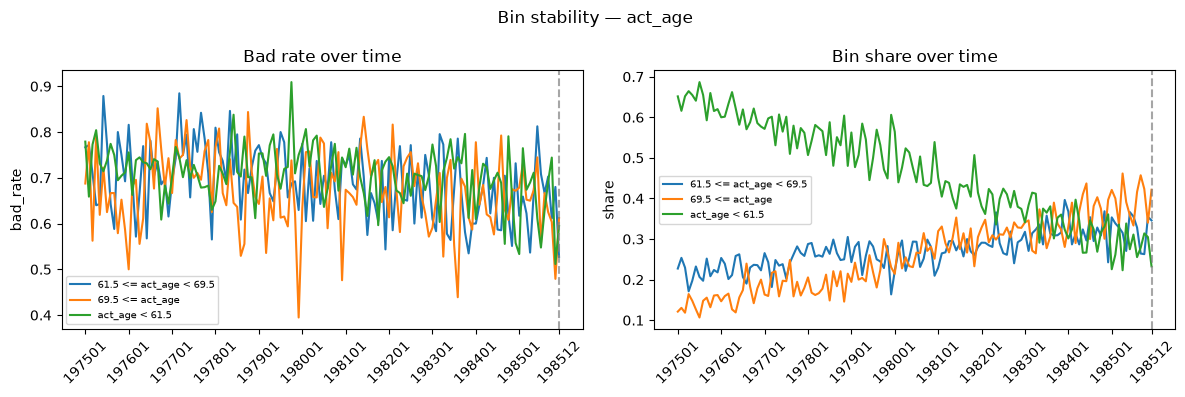

In [35]:
def plot_bin_stability(period_table, feature, train_end_period=None, min_n=None, tick_every=6):
    if period_table.empty:
        return
    min_n = min_n or SCORECARD_PARAMS["min_bin_n_period"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Bin stability — {feature}")

    for bin_label, sub in period_table.groupby("bin"):
        sub = sub.sort_values("period")
        if sub["n"].min() < min_n:
            continue
        axes[0].plot(sub["period"], sub["bad_rate"], label=str(bin_label))
        axes[1].plot(sub["period"], sub["share"], label=str(bin_label))

    if train_end_period:
        for ax in axes:
            ax.axvline(train_end_period, color="gray", linestyle="--", alpha=0.7)

    # keep only some periods on x-axis
    periods = sorted(period_table["period"].astype(str).unique())
    xticks = periods[::tick_every] if len(periods) > tick_every else periods
    if periods[-1] not in xticks:
        xticks.append(periods[-1])

    axes[0].set_title("Bad rate over time")
    axes[0].set_ylabel("bad_rate")
    axes[1].set_title("Bin share over time")
    axes[1].set_ylabel("share")

    for ax in axes:
        ax.set_xticks(xticks)
        ax.tick_params(axis="x", rotation=45)
        ax.legend(fontsize=7, loc="best")

    plt.tight_layout()
    plt.show()

# --- checkpoint: plot_bin_stability ---
_cp_plot_feat = _cp_feats[0]
print(f"checkpoint plot_bin_stability ({_cp_plot_feat}):")
plot_bin_stability(
    _cp_period_tables[_cp_plot_feat],
    _cp_plot_feat,
    train_end_period=SCORECARD_PARAMS["train_end_period"],
    tick_every=12,
)

checkpoint plot_br_gaps_over_time (act_age):


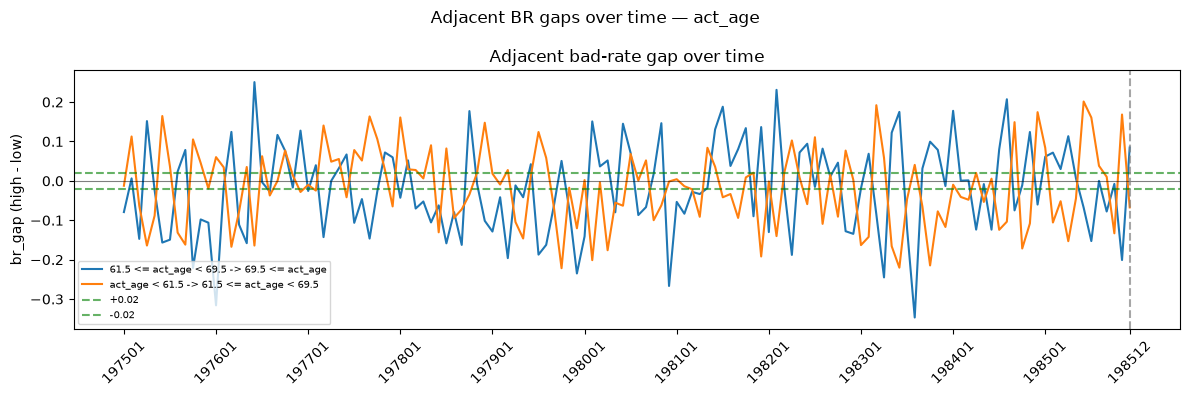

In [36]:
def plot_br_gaps_over_time(period_gaps, feature, train_end_period=None, min_n=None, tick_every=6):
    """Plot adjacent-bin bad-rate gaps over time for eyeballing."""
    if period_gaps is None or period_gaps.empty:
        print("No period gap data to plot")
        return

    min_n = min_n or SCORECARD_PARAMS.get("min_bin_n_period", 10)
    fig, ax = plt.subplots(figsize=(12, 4))
    fig.suptitle(f"Adjacent BR gaps over time — {feature}")

    for pair, sub in period_gaps.groupby("pair"):
        sub = sub.sort_values("period")
        ok = (sub["n_low"] >= min_n) & (sub["n_high"] >= min_n)
        sub = sub.loc[ok]
        if sub.empty:
            continue
        ax.plot(sub["period"], sub["br_gap"], label=str(pair))

    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
    min_gap = SCORECARD_PARAMS.get("min_period_br_gap", 0.02)
    ax.axhline(min_gap, color="green", linestyle="--", alpha=0.6, label=f"+{min_gap}")
    ax.axhline(-min_gap, color="green", linestyle="--", alpha=0.6, label=f"-{min_gap}")

    if train_end_period:
        ax.axvline(train_end_period, color="gray", linestyle="--", alpha=0.7)

    periods = sorted(period_gaps["period"].astype(str).unique())
    xticks = periods[::tick_every] if len(periods) > tick_every else periods
    if periods and periods[-1] not in xticks:
        xticks.append(periods[-1])

    ax.set_title("Adjacent bad-rate gap over time")
    ax.set_ylabel("br_gap (high - low)")
    ax.set_xticks(xticks)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=7, loc="best")
    plt.tight_layout()
    plt.show()

# --- checkpoint: plot_br_gaps_over_time ---
print(f"checkpoint plot_br_gaps_over_time ({_cp_feats[0]}):")
plot_br_gaps_over_time(
    _cp_variable_report[_cp_feats[0]]["period_gaps"],
    _cp_feats[0],
    train_end_period=SCORECARD_PARAMS["train_end_period"],
    tick_every=12,
)


checkpoint plot_woe_ladder (act_age):


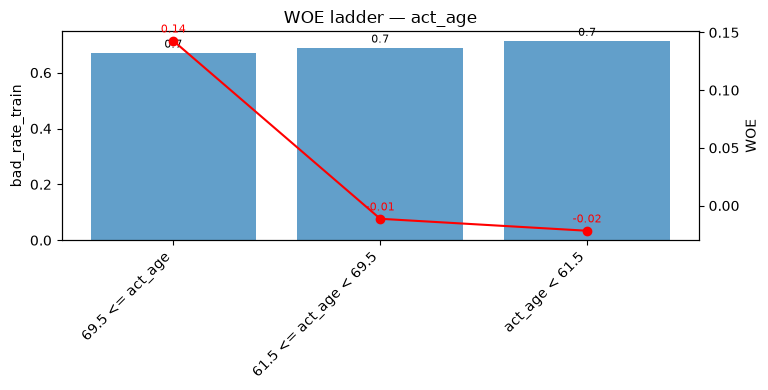

checkpoint plot_woe_monotonic_check (act_age): increasing
WOE monotonicity: increasing


,bin,bad_rate_train,woe,woe_step
0,act_age < 61.5,0.712344,-0.021791,NaN
1,61.5 <= act_age < 69.5,0.688193,-0.011425,0.010366
2,69.5 <= act_age,0.670008,0.142729,0.154154


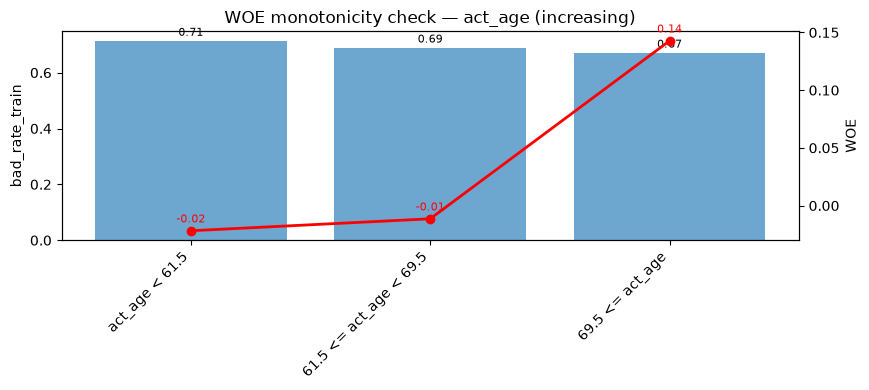

In [37]:
def plot_woe_ladder(woe_maps, big_scorecard, feature):
	grp = f"{feature}_GRP"
	sub = big_scorecard[big_scorecard["variable"] == feature].copy()
	if sub.empty:
		return
	sub = sub.sort_values("bad_rate_train")
	fig, ax1 = plt.subplots(figsize=(8, 4))
	bars = ax1.bar(range(len(sub)), sub["bad_rate_train"].values, alpha=0.7, label="bad_rate_train")
	ax1.bar_label(bars, fmt="%.1f", padding=2, fontsize=8)
	ax1.set_xticks(range(len(sub)))
	ax1.set_xticklabels(sub["bin"].astype(str), rotation=45, ha="right")
	ax1.set_ylabel("bad_rate_train")
	ax2 = ax1.twinx()
	line = ax2.plot(range(len(sub)), sub["woe"].values, color="red", marker="o", label="WOE")[0]
	for x, y in enumerate(sub["woe"].values):
		ax2.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(0, 6),
			ha="center", fontsize=8, color="red")
	ax2.set_ylabel("WOE")
	plt.title(f"WOE ladder — {feature}")
	plt.tight_layout()
	plt.show()

# --- checkpoint: plot_woe_ladder ---
_cp_plot_feat = _cp_feats[0]
print(f"checkpoint plot_woe_ladder ({_cp_plot_feat}):")
plot_woe_ladder(_cp_woe_maps, _cp_big_scorecard, _cp_plot_feat)


def plot_woe_monotonic_check(woe_ordered, feature, direction=None):
    """Plot WOE ladder in bin order for monotonicity eyeballing."""
    if woe_ordered is None or woe_ordered.empty:
        print("No WOE data to plot")
        return

    direction = direction or "unknown"
    print(f"WOE monotonicity: {direction}")
    display(woe_ordered)

    fig, ax1 = plt.subplots(figsize=(9, 4))
    x = range(len(woe_ordered))
    bars = ax1.bar(x, woe_ordered["bad_rate_train"], alpha=0.65, label="bad_rate_train")
    ax1.bar_label(bars, fmt="%.2f", padding=2, fontsize=8)
    ax1.set_xticks(x)
    ax1.set_xticklabels(woe_ordered["bin"].astype(str), rotation=45, ha="right")
    ax1.set_ylabel("bad_rate_train")

    ax2 = ax1.twinx()
    ax2.plot(x, woe_ordered["woe"], color="red", marker="o", linewidth=2, label="WOE")
    for i, y in enumerate(woe_ordered["woe"]):
        ax2.annotate(
            f"{y:.2f}", (i, y), textcoords="offset points", xytext=(0, 6),
            ha="center", fontsize=8, color="red",
        )
    ax2.set_ylabel("WOE")
    plt.title(f"WOE monotonicity check — {feature} ({direction})")
    plt.tight_layout()
    plt.show()

# --- checkpoint: plot_woe_monotonic_check ---
_cp_woe_ordered, _cp_woe_inc, _cp_woe_dec, _cp_woe_dir = check_woe_monotonicity(
    _cp_big_scorecard, _cp_feats[0], _cp_maps
)
print(f"checkpoint plot_woe_monotonic_check ({_cp_feats[0]}): {_cp_woe_dir}")
plot_woe_monotonic_check(_cp_woe_ordered, _cp_feats[0], _cp_woe_dir)


checkpoint plot_bin_bad_rate_bar (act_age):


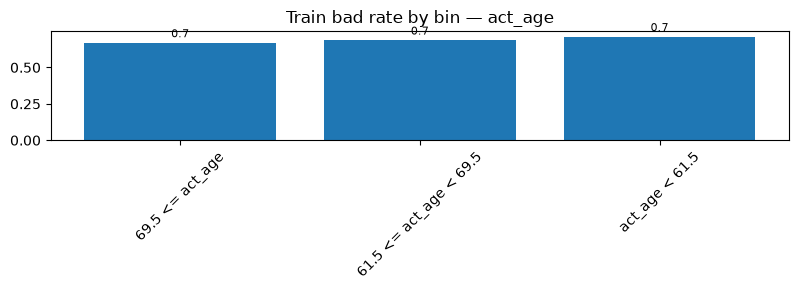

In [38]:
def plot_bin_bad_rate_bar(big_scorecard, variable):
    sub = big_scorecard[big_scorecard["variable"] == variable].sort_values("bad_rate_train")
    if sub.empty:
        return
    fig, ax = plt.subplots(figsize=(8, 3))
    bars = ax.bar(sub["bin"].astype(str), sub["bad_rate_train"])
    ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=8)  # or fmt="%.3f"
    ax.set_title(f"Train bad rate by bin — {variable}")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

# --- checkpoint: plot_bin_bad_rate_bar ---
_cp_plot_feat = _cp_feats[0]
print(f"checkpoint plot_bin_bad_rate_bar ({_cp_plot_feat}):")
plot_bin_bad_rate_bar(_cp_big_scorecard, _cp_plot_feat)


checkpoint plot_stability_heatmap (act_age):


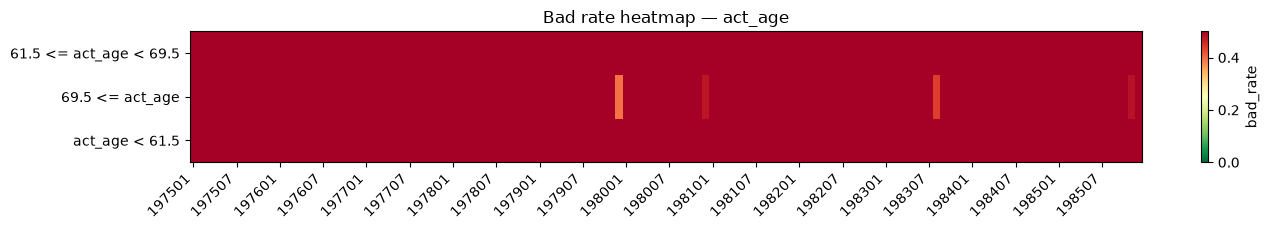

In [39]:
def plot_stability_heatmap(period_table, feature):
	if period_table.empty:
		return
	pivot = period_table.pivot(index="bin", columns="period", values="bad_rate")
	fig, ax = plt.subplots(figsize=(14, max(2, len(pivot) * 0.8)))
	im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=0.5)
	ax.set_yticks(range(len(pivot)))
	ax.set_yticklabels(pivot.index.astype(str))
	ax.set_xticks(range(0, len(pivot.columns), 6))
	ax.set_xticklabels(pivot.columns[::6], rotation=45, ha="right")
	ax.set_title(f"Bad rate heatmap — {feature}")
	plt.colorbar(im, ax=ax, label="bad_rate")
	plt.tight_layout()
	plt.show()

# --- checkpoint: plot_stability_heatmap ---
_cp_plot_feat = _cp_feats[0]
print(f"checkpoint plot_stability_heatmap ({_cp_plot_feat}):")
plot_stability_heatmap(_cp_period_tables[_cp_plot_feat], _cp_plot_feat)


checkpoint display_variable_report (act_age):
### act_age
Static bins (Big_scorecard left block)


,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
0,61.5 <= act_age < 69.5,61.5 <= act_age < 69.5,0.688193,0.271551,5141,3538,1603,-0.011425
1,69.5 <= act_age,69.5 <= act_age,0.670008,0.258187,4888,3275,1613,0.142729
2,act_age < 61.5,act_age < 61.5,0.712344,0.470262,8903,6342,2561,-0.021791


WOE monotonicity check
WOE monotonicity: increasing


,bin,bad_rate_train,woe,woe_step
0,act_age < 61.5,0.712344,-0.021791,NaN
1,61.5 <= act_age < 69.5,0.688193,-0.011425,0.010366
2,69.5 <= act_age,0.670008,0.142729,0.154154


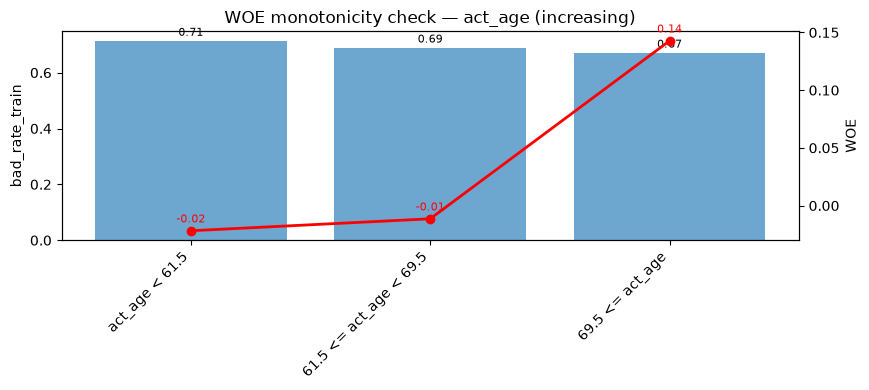

Adjacent bad-rate gaps (static)


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid,pass_min_gap_train,pass_min_gap_valid
0,act_age,act_age < 61.5,61.5 <= act_age < 69.5,0.712344,0.688193,-0.024151,0.024151,0.665885,0.643004,-0.022881,0.022881,True,True
1,act_age,61.5 <= act_age < 69.5,69.5 <= act_age,0.688193,0.670008,-0.018185,0.018185,0.643004,0.581579,-0.061425,0.061425,False,True


Adjacent bad-rate gaps over time (head)


,variable,period,bin_low,bin_high,pair,br_low,br_high,br_gap,abs_br_gap,n_low,n_high
0,act_age,197501,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.779070,0.766667,-0.012403,0.012403,86,30
1,act_age,197501,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.766667,0.687500,-0.079167,0.079167,30,16
2,act_age,197502,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.658824,0.771429,0.112605,0.112605,85,35
3,act_age,197502,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.771429,0.777778,0.006349,0.006349,35,18
4,act_age,197503,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.772727,0.709677,-0.063050,0.063050,88,31
5,act_age,197503,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.709677,0.562500,-0.147177,0.147177,31,16
6,act_age,197504,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.804124,0.640000,-0.164124,0.164124,97,25
7,act_age,197504,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.640000,0.791667,0.151667,0.151667,25,24
8,act_age,197505,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.731183,0.642857,-0.088326,0.088326,93,28
9,act_age,197505,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.642857,0.619048,-0.023810,0.023810,28,21


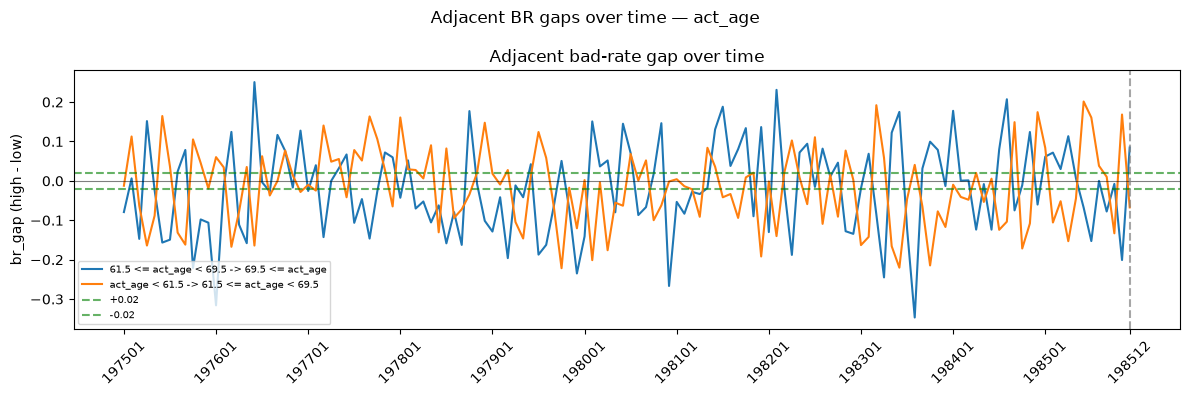

Period × bin (Variable_report right block)


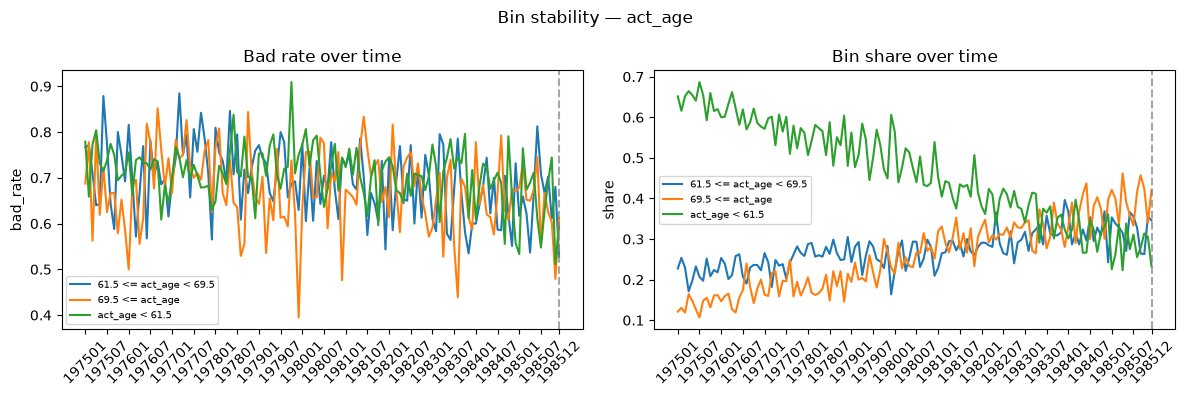

In [40]:
def display_variable_report(variable_report, feature):
    block = variable_report[feature]
    print(f"### {feature}")
    print("Static bins (Big_scorecard left block)")
    display(block["static"])

    woe_ordered = block.get("woe_ordered", pd.DataFrame())
    woe_mono = block.get("woe_monotonic", {})
    if woe_ordered is not None and len(woe_ordered):
        print("WOE monotonicity check")
        plot_woe_monotonic_check(
            woe_ordered,
            feature,
            direction=woe_mono.get("direction", "unknown"),
        )

    static_gaps = block.get("static_gaps", pd.DataFrame())
    if static_gaps is not None and len(static_gaps):
        print("Adjacent bad-rate gaps (static)")
        min_gap = SCORECARD_PARAMS.get("min_static_br_gap", 0.02)
        gaps_view = static_gaps.copy()
        gaps_view["pass_min_gap_train"] = gaps_view["abs_br_gap_train"] >= min_gap
        gaps_view["pass_min_gap_valid"] = gaps_view["abs_br_gap_valid"] >= min_gap
        display(gaps_view)

    period_gaps = block.get("period_gaps", pd.DataFrame())
    if period_gaps is not None and len(period_gaps):
        print("Adjacent bad-rate gaps over time (head)")
        display(period_gaps.head(20))
        plot_br_gaps_over_time(
            period_gaps,
            feature,
            train_end_period=SCORECARD_PARAMS["train_end_period"],
            tick_every=12,
        )

    print("Period × bin (Variable_report right block)")
    plot_bin_stability(
        block["period"],
        feature,
        train_end_period=SCORECARD_PARAMS["train_end_period"],
    )

# --- checkpoint: display_variable_report ---
_cp_plot_feat = _cp_feats[0]
print(f"checkpoint display_variable_report ({_cp_plot_feat}):")
display_variable_report(_cp_variable_report, _cp_plot_feat)


### §2 — Bin tuning exec + gate

In [41]:
# §2A — Auto binning baseline
binning_maps = fit_binning_maps(train_product, cand["all"], SCORECARD_PARAMS["target"], SCORECARD_PARAMS)

train_binned = apply_bins(train_product, binning_maps)
valid_binned = apply_bins(valid_product, binning_maps)

grp_cols = [f"{f}_GRP" for f in cand["all"] if f"{f}_GRP" in train_binned.columns]
woe_maps = build_woe_maps(train_binned, grp_cols, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["woe_epsilon"])
iv_table = build_iv_table(woe_maps)

train_woe = encode_woe(train_binned, woe_maps)
valid_woe = encode_woe(valid_binned, woe_maps)

big_scorecard = build_big_scorecard(
    train_binned, valid_binned, woe_maps, binning_maps,
    SCORECARD_PARAMS["target"], SCORECARD_PARAMS
)
print("Auto binning ready:", len(binning_maps))
display(binning_maps[_cp_feats[0]])

Auto binning ready: 56


{'type': 'numeric',
 'feature': 'act_age',
 'edges': [-inf, np.float64(61.5), np.float64(69.5), inf],
 'intervals': ['act_age < 61.5', '61.5 <= act_age < 69.5', '69.5 <= act_age'],
 'missing_label': 'Missing',
 'missing_bin': np.False_}

edges: [-inf, np.float64(61.5), np.float64(69.5), inf]
intervals: ['act_age < 61.5', '61.5 <= act_age < 69.5', '69.5 <= act_age']
### act_age
Static bins (Big_scorecard left block)


,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
0,61.5 <= act_age < 69.5,61.5 <= act_age < 69.5,0.688193,0.271551,5141,3538,1603,0.031233
1,69.5 <= act_age,69.5 <= act_age,0.670008,0.258187,4888,3275,1613,0.114695
2,act_age < 61.5,act_age < 61.5,0.712344,0.470262,8903,6342,2561,-0.083879


WOE monotonicity check
WOE monotonicity: increasing


,bin,bad_rate_train,woe,woe_step
0,act_age < 61.5,0.712344,-0.083879,NaN
1,61.5 <= act_age < 69.5,0.688193,0.031233,0.115112
2,69.5 <= act_age,0.670008,0.114695,0.083463


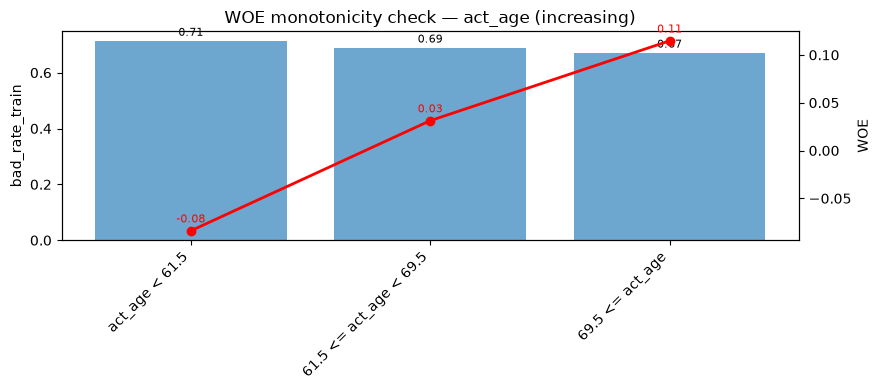

Adjacent bad-rate gaps (static)


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid,pass_min_gap_train,pass_min_gap_valid
0,act_age,act_age < 61.5,61.5 <= act_age < 69.5,0.712344,0.688193,-0.024151,0.024151,0.665885,0.643004,-0.022881,0.022881,True,True
1,act_age,61.5 <= act_age < 69.5,69.5 <= act_age,0.688193,0.670008,-0.018185,0.018185,0.643004,0.581579,-0.061425,0.061425,False,True


Adjacent bad-rate gaps over time (head)


,variable,period,bin_low,bin_high,pair,br_low,br_high,br_gap,abs_br_gap,n_low,n_high
0,act_age,197501,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.779070,0.766667,-0.012403,0.012403,86,30
1,act_age,197501,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.766667,0.687500,-0.079167,0.079167,30,16
2,act_age,197502,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.658824,0.771429,0.112605,0.112605,85,35
3,act_age,197502,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.771429,0.777778,0.006349,0.006349,35,18
4,act_age,197503,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.772727,0.709677,-0.063050,0.063050,88,31
5,act_age,197503,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.709677,0.562500,-0.147177,0.147177,31,16
6,act_age,197504,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.804124,0.640000,-0.164124,0.164124,97,25
7,act_age,197504,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.640000,0.791667,0.151667,0.151667,25,24
8,act_age,197505,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.731183,0.642857,-0.088326,0.088326,93,28
9,act_age,197505,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.642857,0.619048,-0.023810,0.023810,28,21


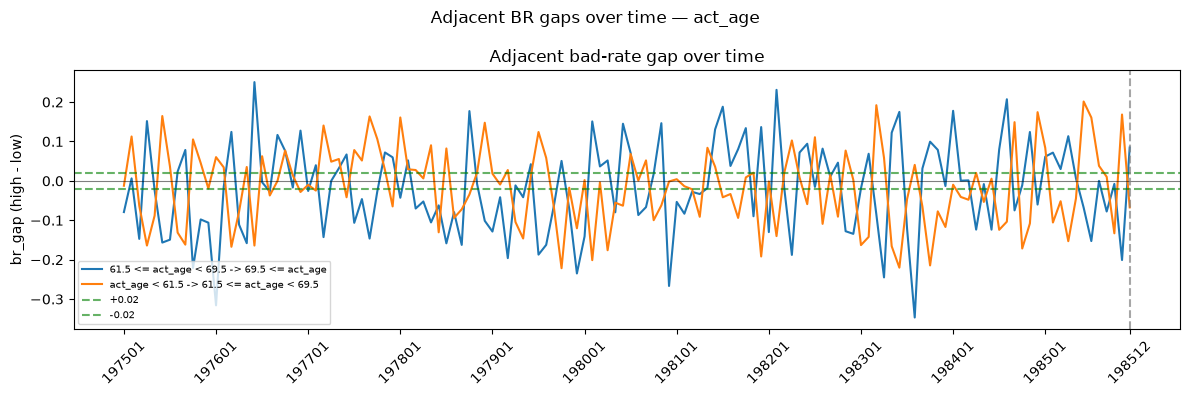

Period × bin (Variable_report right block)


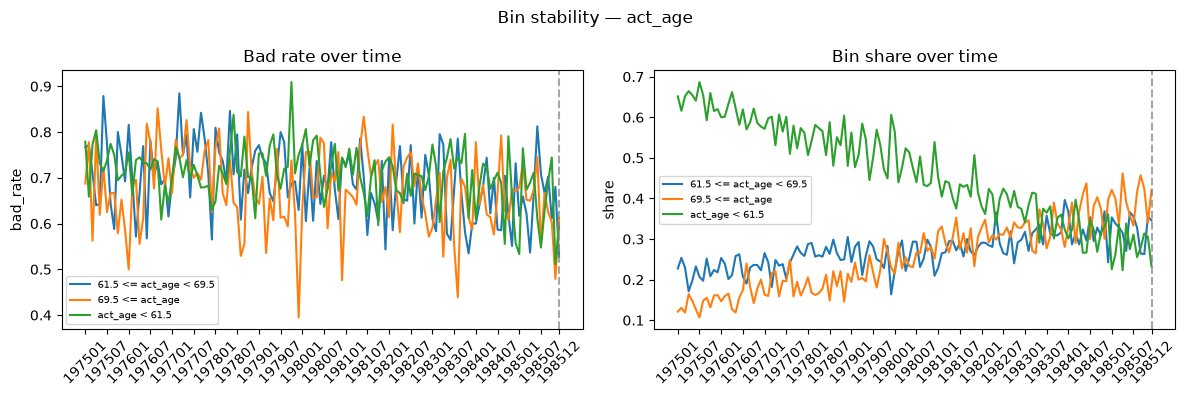

,min_n,max_n,periods
bin,,,
69.5 <= act_age,16,67,132
61.5 <= act_age < 69.5,25,65,132
act_age < 61.5,29,111,132


In [42]:
# §2B — Manual review (one feature)
feature_to_review = "act_age"

# show current bin spec we are editing
spec = binning_maps.get(feature_to_review)
print("edges:", spec.get("edges"))
print("intervals:", spec.get("intervals"))

# build one-feature report and reuse existing display helper
period_tables, _ = bin_stability_report(
    train_binned, [feature_to_review],
    SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS
)
variable_report = build_variable_report(
    train_binned, big_scorecard, [feature_to_review],
    SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
    period_tables=period_tables,
    binning_maps=binning_maps,
)
display_variable_report(variable_report, feature_to_review)

# optional diagnostic only (why a bin line is missing)
pt = period_tables[feature_to_review]
display(
    pt.groupby("bin")
      .agg(min_n=("n", "min"), max_n=("n", "max"), periods=("period", "nunique"))
      .sort_values("min_n")
)

In [43]:
# §2C — Apply manual bin overrides and rebuild
manual_binning_overrides = {
    "act_age": {'type': 'numeric',
                'feature': 'act_age',
                'edges': [-np.inf, np.float64(62), np.inf],
                'intervals': ['act_age < 62', '62 <= act_age'],
                'missing_label': 'Missing',
                'missing_bin': np.False_},
    # "act_cc": {...full numeric spec...},
}

for feat, spec in manual_binning_overrides.items():
    binning_maps[feat] = spec

train_binned = apply_bins(train_product, binning_maps)
valid_binned = apply_bins(valid_product, binning_maps)

grp_cols = [f"{f}_GRP" for f in cand["all"] if f"{f}_GRP" in train_binned.columns]
woe_maps = build_woe_maps(train_binned, grp_cols, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["woe_epsilon"])
iv_table = build_iv_table(woe_maps)
train_woe = encode_woe(train_binned, woe_maps)
valid_woe = encode_woe(valid_binned, woe_maps)

print("Manual overrides applied:", sorted(manual_binning_overrides.keys()))

Manual overrides applied: ['act_age']


edges: [-inf, np.float64(62.0), inf]
intervals: ['act_age < 62', '62 <= act_age']
### act_age
Static bins (Big_scorecard left block)


,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
0,61.5 <= act_age < 69.5,61.5 <= act_age < 69.5,0.688193,0.271551,5141,3538,1603,0.031233
1,69.5 <= act_age,69.5 <= act_age,0.670008,0.258187,4888,3275,1613,0.114695
2,act_age < 61.5,act_age < 61.5,0.712344,0.470262,8903,6342,2561,-0.083879


Adjacent bad-rate gaps over time (head)


,variable,period,bin_low,bin_high,pair,br_low,br_high,br_gap,abs_br_gap,n_low,n_high
0,act_age,197501,act_age < 62,62 <= act_age,act_age < 62 -> 62 <= act_age,0.779070,0.739130,-0.039939,0.039939,86,46
1,act_age,197502,act_age < 62,62 <= act_age,act_age < 62 -> 62 <= act_age,0.658824,0.773585,0.114761,0.114761,85,53
2,act_age,197503,act_age < 62,62 <= act_age,act_age < 62 -> 62 <= act_age,0.772727,0.659574,-0.113153,0.113153,88,47
3,act_age,197504,act_age < 62,62 <= act_age,act_age < 62 -> 62 <= act_age,0.804124,0.714286,-0.089838,0.089838,97,49
4,act_age,197505,act_age < 62,62 <= act_age,act_age < 62 -> 62 <= act_age,0.731183,0.632653,-0.098530,0.098530,93,49
5,act_age,197506,act_age < 62,62 <= act_age,act_age < 62 -> 62 <= act_age,0.714286,0.823529,0.109244,0.109244,91,51
6,act_age,197507,act_age < 62,62 <= act_age,act_age < 62 -> 62 <= act_age,0.737864,0.723404,-0.014460,0.014460,103,47
7,act_age,197508,act_age < 62,62 <= act_age,act_age < 62 -> 62 <= act_age,0.774194,0.653061,-0.121132,0.121132,93,49
8,act_age,197509,act_age < 62,62 <= act_age,act_age < 62 -> 62 <= act_age,0.750000,0.618182,-0.131818,0.131818,80,55
9,act_age,197510,act_age < 62,62 <= act_age,act_age < 62 -> 62 <= act_age,0.694737,0.714286,0.019549,0.019549,95,49


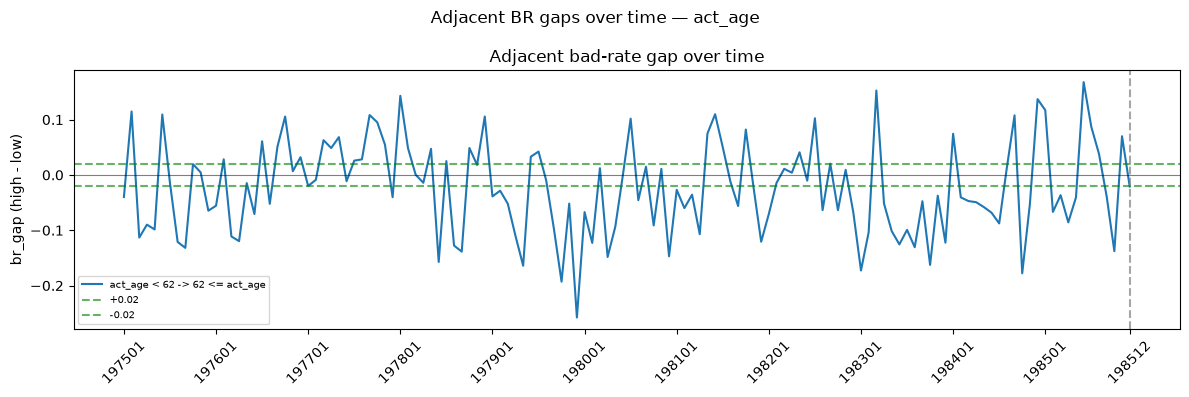

Period × bin (Variable_report right block)


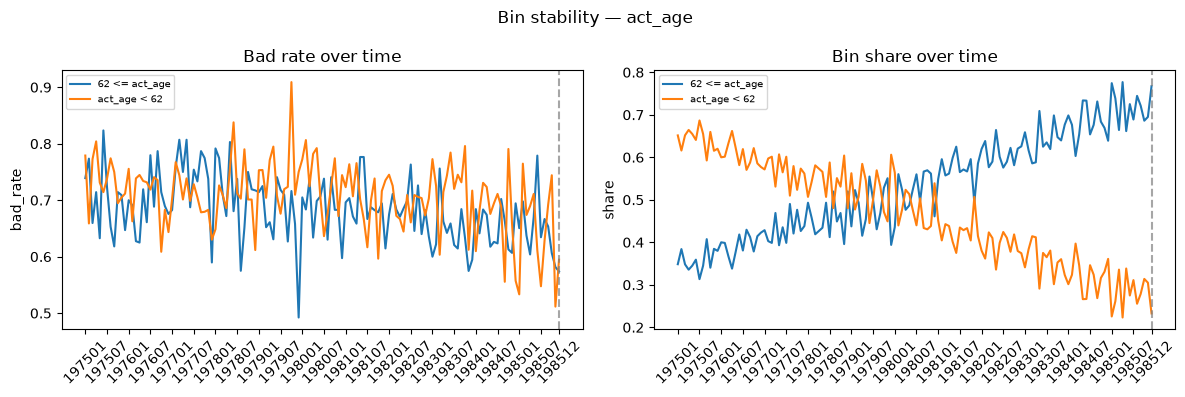

,min_n,max_n,periods
bin,,,
act_age < 62,29,111,132
62 <= act_age,46,122,132


In [44]:
# §2C.1 — Manual review after overrides
feature_to_review = "act_age"

# show current bin spec we are editing
spec = binning_maps.get(feature_to_review)
print("edges:", spec.get("edges"))
print("intervals:", spec.get("intervals"))

# build one-feature report and reuse existing display helper
period_tables, _ = bin_stability_report(
    train_binned, [feature_to_review],
    SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS
)
variable_report = build_variable_report(
    train_binned, big_scorecard, [feature_to_review],
    SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
    period_tables=period_tables,
    binning_maps=binning_maps,
)
display_variable_report(variable_report, feature_to_review)

# optional diagnostic only (why a bin line is missing)
pt = period_tables[feature_to_review]
display(
    pt.groupby("bin")
      .agg(min_n=("n", "min"), max_n=("n", "max"), periods=("period", "nunique"))
      .sort_values("min_n")
)


In [45]:
# §2D — Quality checks + manual-review table for §3
big_scorecard = build_big_scorecard(
    train_binned, valid_binned, woe_maps, binning_maps,
    SCORECARD_PARAMS["target"], SCORECARD_PARAMS
)

gini_vars = build_gini_vars_table(
    train_binned, valid_binned, train_woe, valid_woe,
    big_scorecard, cand["all"], SCORECARD_PARAMS["target"], SCORECARD_PARAMS
)

review_vars = apply_prescreen(gini_vars, SCORECARD_PARAMS)
_, stability_flags = bin_stability_report(
    train_binned, cand["all"], SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS
)
master_review_vars, master_review_bins = build_master_review_table(review_vars, stability_flags)
vars_selected = select_vars_from_manual_review(master_review_vars)

print(f"auto-safe variables: {int(master_review_vars['safe_to_include'].sum())} / {len(master_review_vars)}")
print(f"vars_selected (manual_decision='keep'): {len(vars_selected)}")
display(master_review_vars.head(15))
display(master_review_bins.head(20))

auto-safe variables: 0 / 56
vars_selected (manual_decision='keep'): 0


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique,pass_gini_train,pass_delta_gini,pass_psi_tar,pass_psi,pass_iv,safe_to_include,safety_reason,manual_decision,manual_note,n_bins,n_unstable_bins,max_bad_rate_swing,max_min_n_period,review_plot_order
0,app_char_marital_status,0.068337,0.083234,0.218002,0.022653,0.097596,0.093190,0.000000,4,True,False,True,True,True,False,delta_gini < 0.2 failed; stability flags present,review,,4,4,1.000000,42,1
1,app_char_job_code,0.056565,0.047100,0.167325,0.041900,0.119227,0.094511,0.000000,4,True,True,True,True,True,False,stability flags present,review,,4,4,1.000000,67,2
2,act6_n_arrears_days,0.278359,0.309502,0.111881,0.436166,0.000435,0.004283,0.000000,5,True,True,True,True,True,False,stability flags present,review,,4,4,1.000000,79,3
3,act_ccss_n_loan,0.446525,0.398244,0.108126,0.768659,0.004650,0.007954,0.000000,7,True,True,True,True,True,False,stability flags present,review,,4,4,1.000000,60,4
4,act9_n_good_days,0.156634,0.143735,0.082355,0.106086,0.000338,0.001794,0.000000,10,True,True,True,True,True,False,stability flags present,review,,4,4,1.000000,78,5
5,act_call_n_loan,0.379348,0.357780,0.056856,0.531550,0.003781,0.006337,0.000000,9,True,True,True,True,True,False,stability flags present,review,,4,4,1.000000,41,6
6,act9_n_arrears_days,0.324470,0.341575,0.052715,0.505748,0.001522,0.007305,0.000000,6,True,True,True,True,True,False,stability flags present,review,,4,4,1.000000,68,7
7,act6_n_good_days,0.112108,0.113265,0.010323,0.073902,0.003169,0.004315,0.000000,7,True,True,True,True,True,False,stability flags present,review,,4,4,1.000000,70,8
8,act_ccss_n_statB,0.195166,0.184827,0.052975,0.136070,0.140561,0.171185,0.287661,41,True,True,False,True,True,False,psi_tar < 0.1 failed; stability flags present,review,,4,4,0.666667,19,9
9,act6_n_arrears,0.583223,0.605973,0.039007,1.386991,0.010881,0.000023,0.000000,7,True,True,True,True,True,False,stability flags present,review,,4,4,0.633333,61,10


,variable,bin,n_periods,min_bad_rate,max_bad_rate,bad_rate_swing,min_n_period,total_n,flag_unstable,flag_reason,safe_to_include,safety_reason,manual_decision,review_plot_order
0,act12_n_arrears,4.5 <= act12_n_arrears < 9.5,132,0.441176,0.903226,0.462049,19,4533,True,swing>0.15,False,stability flags present,review,31
1,act12_n_arrears,9.5 <= act12_n_arrears,132,0.762712,0.972973,0.210261,51,9280,True,swing>0.15,False,stability flags present,review,31
2,act12_n_arrears,act12_n_arrears < 4.5,132,0.135135,0.500000,0.364865,23,5119,True,swing>0.15,False,stability flags present,review,31
3,act12_n_arrears_days,1,132,0.666667,1.000000,0.333333,5,2210,True,swing>0.15; min_n_period<10,False,stability flags present,review,11
4,act12_n_arrears_days,2,132,0.404762,0.716216,0.311454,64,11015,True,swing>0.15,False,stability flags present,review,11
5,act12_n_arrears_days,3,132,0.714286,1.000000,0.285714,23,4742,True,swing>0.15,False,stability flags present,review,11
6,act12_n_arrears_days,<OTHERS>,132,0.400000,1.000000,0.600000,2,965,True,swing>0.15; min_n_period<10,False,stability flags present,review,11
7,act12_n_good_days,3.5 <= act12_n_good_days < 6.5,132,0.655738,0.913793,0.258055,48,8534,True,swing>0.15,False,stability flags present,review,30
8,act12_n_good_days,6.5 <= act12_n_good_days,132,0.363636,0.833333,0.469697,15,3885,True,swing>0.15,False,stability flags present,review,30
9,act12_n_good_days,act12_n_good_days < 3.5,132,0.478261,0.795455,0.317194,35,6513,True,swing>0.15,False,stability flags present,review,30


In [46]:
# §2 — Bin tuning loop (re-run after changing params until manual-review table is stable)

binning_maps = fit_binning_maps(
    train_product, cand["all"], SCORECARD_PARAMS["target"], SCORECARD_PARAMS
)
train_binned = apply_bins(train_product, binning_maps)
valid_binned = apply_bins(valid_product, binning_maps)

grp_cols = [f"{f}_GRP" for f in cand["all"] if f"{f}_GRP" in train_binned.columns]
woe_maps = build_woe_maps(
    train_binned, grp_cols, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["woe_epsilon"]
)
iv_table = build_iv_table(woe_maps)
train_woe = encode_woe(train_binned, woe_maps)
valid_woe = encode_woe(valid_binned, woe_maps)

big_scorecard = build_big_scorecard(
    train_binned, valid_binned, woe_maps, binning_maps,
    SCORECARD_PARAMS["target"], SCORECARD_PARAMS,
)
print("big_scorecard rows:", len(big_scorecard))
display(big_scorecard.head(10))

gini_vars = build_gini_vars_table(
    train_binned, valid_binned, train_woe, valid_woe,
    big_scorecard, cand["all"], SCORECARD_PARAMS["target"], SCORECARD_PARAMS,
)
review_vars = apply_prescreen(gini_vars, SCORECARD_PARAMS)
period_tables, stability_flags = bin_stability_report(
    train_binned, cand["all"], SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
)
master_review_vars, master_review_bins = build_master_review_table(review_vars, stability_flags)

vars_selected = select_vars_from_manual_review(master_review_vars)
review_focus = master_review_vars.loc[~master_review_vars["safe_to_include"]]
print(f"auto-safe: {int(master_review_vars['safe_to_include'].sum())} / {len(master_review_vars)}")
print(f"vars_selected (manual_decision='keep'): {len(vars_selected)} of {len(master_review_vars)}")
display(master_review_vars.head(20))
display(master_review_bins.head(20))
display(review_focus[["variable", "safety_reason", "n_unstable_bins", "max_bad_rate_swing"]].head(20))

screen_report = prescreen_features(train_woe, valid_woe, iv_table, SCORECARD_PARAMS)
display(screen_report.groupby("status").size())


big_scorecard rows: 163


,variable,bin,condition,n_train,bads_train,goods_train,bad_rate_train,share_train,n_valid,bads_valid,goods_valid,bad_rate_valid,share_valid,woe,iv_component,psi_bin,psi_bad
0,act_age,61.5 <= act_age < 69.5,61.5 <= act_age < 69.5,5141,3538,1603,0.688193,0.271551,972.0,625.0,347.0,0.643004,0.290583,0.031233,0.000266,0.001289,0.003589
1,act_age,69.5 <= act_age,69.5 <= act_age,4888,3275,1613,0.670008,0.258187,1520.0,884.0,636.0,0.581579,0.454410,0.114695,0.003470,0.110894,0.094706
2,act_age,act_age < 61.5,act_age < 61.5,8903,6342,2561,0.712344,0.470262,853.0,568.0,285.0,0.665885,0.255007,-0.083879,0.003254,0.131697,0.118248
3,act_cc,0.506 <= act_cc < 0.636,0.506 <= act_cc < 0.636,5401,3697,1704,0.684503,0.285284,1040.0,655.0,385.0,0.629808,0.310912,0.048374,0.000674,0.002204,0.003954
4,act_cc,0.636 <= act_cc,0.636 <= act_cc,6844,5317,1527,0.776885,0.361504,1375.0,921.0,454.0,0.669818,0.411061,-0.424687,0.059395,0.006365,0.003636
5,act_cc,act_cc < 0.506,act_cc < 0.506,6687,4141,2546,0.619261,0.353211,930.0,501.0,429.0,0.538710,0.278027,0.336504,0.042375,0.017990,0.019578
6,act_loaninc,2.325 <= act_loaninc < 5.817,2.325 <= act_loaninc < 5.817,9751,6390,3361,0.655317,0.515054,1913.0,1125.0,788.0,0.588082,0.571898,0.180422,0.017328,0.005950,0.006088
7,act_loaninc,5.817 <= act_loaninc,5.817 <= act_loaninc,4770,3740,1030,0.784067,0.251954,943.0,657.0,286.0,0.696713,0.281913,-0.466609,0.049465,0.003365,0.003416
8,act_loaninc,act_loaninc < 2.325,act_loaninc < 2.325,4411,3025,1386,0.685786,0.232992,489.0,295.0,194.0,0.603272,0.146188,0.042428,0.000423,0.040438,0.042337
9,app_income,2150.5 <= app_income,2150.5 <= app_income,4411,3025,1386,0.685786,0.232992,489.0,295.0,194.0,0.603272,0.146188,0.042428,0.000423,0.040438,0.042337


auto-safe: 0 / 56
vars_selected (manual_decision='keep'): 0 of 56


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique,pass_gini_train,pass_delta_gini,pass_psi_tar,pass_psi,pass_iv,safe_to_include,safety_reason,manual_decision,manual_note,n_bins,n_unstable_bins,max_bad_rate_swing,max_min_n_period,review_plot_order
0,app_char_marital_status,0.068337,0.083234,0.218002,0.022653,0.097596,0.093190,0.000000,4,True,False,True,True,True,False,delta_gini < 0.2 failed; stability flags present,review,,4,4,1.000000,42,1
1,app_char_job_code,0.056565,0.047100,0.167325,0.041900,0.119227,0.094511,0.000000,4,True,True,True,True,True,False,stability flags present,review,,4,4,1.000000,67,2
2,act6_n_arrears_days,0.278359,0.309502,0.111881,0.436166,0.000435,0.004283,0.000000,5,True,True,True,True,True,False,stability flags present,review,,4,4,1.000000,79,3
3,act_ccss_n_loan,0.446525,0.398244,0.108126,0.768659,0.004650,0.007954,0.000000,7,True,True,True,True,True,False,stability flags present,review,,4,4,1.000000,60,4
4,act9_n_good_days,0.156634,0.143735,0.082355,0.106086,0.000338,0.001794,0.000000,10,True,True,True,True,True,False,stability flags present,review,,4,4,1.000000,78,5
5,act_call_n_loan,0.379348,0.357780,0.056856,0.531550,0.003781,0.006337,0.000000,9,True,True,True,True,True,False,stability flags present,review,,4,4,1.000000,41,6
6,act9_n_arrears_days,0.324470,0.341575,0.052715,0.505748,0.001522,0.007305,0.000000,6,True,True,True,True,True,False,stability flags present,review,,4,4,1.000000,68,7
7,act6_n_good_days,0.112108,0.113265,0.010323,0.073902,0.003169,0.004315,0.000000,7,True,True,True,True,True,False,stability flags present,review,,4,4,1.000000,70,8
8,act_ccss_n_statB,0.195166,0.184827,0.052975,0.136070,0.140561,0.171185,0.287661,41,True,True,False,True,True,False,psi_tar < 0.1 failed; stability flags present,review,,4,4,0.666667,19,9
9,act6_n_arrears,0.583223,0.605973,0.039007,1.386991,0.010881,0.000023,0.000000,7,True,True,True,True,True,False,stability flags present,review,,4,4,0.633333,61,10


,variable,bin,n_periods,min_bad_rate,max_bad_rate,bad_rate_swing,min_n_period,total_n,flag_unstable,flag_reason,safe_to_include,safety_reason,manual_decision,review_plot_order
0,act12_n_arrears,4.5 <= act12_n_arrears < 9.5,132,0.441176,0.903226,0.462049,19,4533,True,swing>0.15,False,stability flags present,review,31
1,act12_n_arrears,9.5 <= act12_n_arrears,132,0.762712,0.972973,0.210261,51,9280,True,swing>0.15,False,stability flags present,review,31
2,act12_n_arrears,act12_n_arrears < 4.5,132,0.135135,0.500000,0.364865,23,5119,True,swing>0.15,False,stability flags present,review,31
3,act12_n_arrears_days,1,132,0.666667,1.000000,0.333333,5,2210,True,swing>0.15; min_n_period<10,False,stability flags present,review,11
4,act12_n_arrears_days,2,132,0.404762,0.716216,0.311454,64,11015,True,swing>0.15,False,stability flags present,review,11
5,act12_n_arrears_days,3,132,0.714286,1.000000,0.285714,23,4742,True,swing>0.15,False,stability flags present,review,11
6,act12_n_arrears_days,<OTHERS>,132,0.400000,1.000000,0.600000,2,965,True,swing>0.15; min_n_period<10,False,stability flags present,review,11
7,act12_n_good_days,3.5 <= act12_n_good_days < 6.5,132,0.655738,0.913793,0.258055,48,8534,True,swing>0.15,False,stability flags present,review,30
8,act12_n_good_days,6.5 <= act12_n_good_days,132,0.363636,0.833333,0.469697,15,3885,True,swing>0.15,False,stability flags present,review,30
9,act12_n_good_days,act12_n_good_days < 3.5,132,0.478261,0.795455,0.317194,35,6513,True,swing>0.15,False,stability flags present,review,30


,variable,safety_reason,n_unstable_bins,max_bad_rate_swing
0,app_char_marital_status,delta_gini < 0.2 failed; stability flags present,4,1.000000
1,app_char_job_code,stability flags present,4,1.000000
2,act6_n_arrears_days,stability flags present,4,1.000000
3,act_ccss_n_loan,stability flags present,4,1.000000
4,act9_n_good_days,stability flags present,4,1.000000
5,act_call_n_loan,stability flags present,4,1.000000
6,act9_n_arrears_days,stability flags present,4,1.000000
7,act6_n_good_days,stability flags present,4,1.000000
8,act_ccss_n_statB,psi_tar < 0.1 failed; stability flags present,4,0.666667
9,act6_n_arrears,stability flags present,4,0.633333


status
keep      42
reject    14
dtype: int64

In [47]:
thin_bins = big_scorecard.loc[
    (big_scorecard["variable"].isin(vars_selected))
    & (big_scorecard["share_train"] < SCORECARD_PARAMS["minimum_share_int"])
]
print(
    f"§2 check — PRODUCT={PRODUCT} vars_selected={len(vars_selected)} "
    f"thin_bins={len(thin_bins)}"
)
if len(vars_selected) >= 10 and thin_bins.empty:
    print("§2 PASS — proceed to §3")
else:
    print("§2 NOT PASS — tune SCORECARD_PARAMS and re-run §2 block above")
    if len(thin_bins):
        display(thin_bins[["variable", "bin", "share_train"]].head(20))


§2 check — PRODUCT=css vars_selected=0 thin_bins=0
§2 NOT PASS — tune SCORECARD_PARAMS and re-run §2 block above


,review_plot_order,variable,safety_reason
0,1,app_char_marital_status,delta_gini < 0.2 failed; stability flags present
1,2,app_char_job_code,stability flags present
2,3,act6_n_arrears_days,stability flags present
3,4,act_ccss_n_loan,stability flags present
4,5,act9_n_good_days,stability flags present
5,6,act_call_n_loan,stability flags present
6,7,act9_n_arrears_days,stability flags present
7,8,act6_n_good_days,stability flags present
8,9,act_ccss_n_statB,psi_tar < 0.1 failed; stability flags present
9,10,act6_n_arrears,stability flags present


feature_to_review: app_char_marital_status
edges: None
intervals: ['Widowed', 'Divorced', 'Maried']


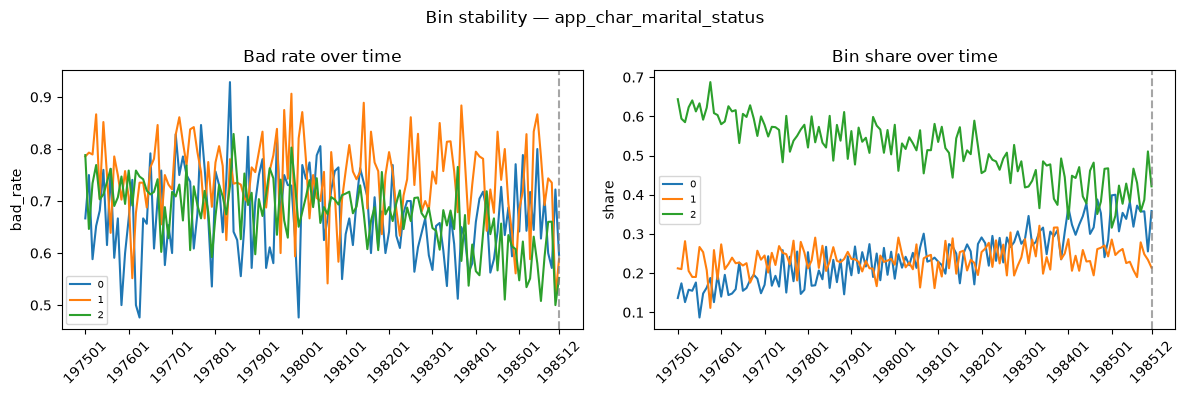

In [48]:
# §2f — Manual stability review (one feature at a time)
# If you leave feature_to_review as None, it picks the first unsafe variable by review order.
feature_to_review = None

target = SCORECARD_PARAMS["target"]
time_col = SCORECARD_PARAMS["time_col"]

if "master_review_vars" in globals() and len(master_review_vars):
    unsafe_queue = master_review_vars.loc[
        ~master_review_vars["safe_to_include"], ["review_plot_order", "variable", "safety_reason"]
    ].sort_values("review_plot_order")
    if feature_to_review is None and len(unsafe_queue):
        feature_to_review = unsafe_queue.iloc[0]["variable"]
    display(unsafe_queue.head(15))

if feature_to_review not in cand["all"]:
    print(f"Feature '{feature_to_review}' is not in candidate list")
else:
    spec = binning_maps.get(feature_to_review, {})
    print(f"feature_to_review: {feature_to_review}")
    print("edges:", spec.get("edges"))
    print("intervals:", spec.get("intervals"))

    period_tbl = bin_bad_rate_by_period(train_binned, feature_to_review, target, time_col)
    plot_bin_stability(
        period_tbl,
        feature_to_review,
        train_end_period=SCORECARD_PARAMS["train_end_period"],
        tick_every=12,
    )


In [49]:
# §2f.1 — Apply manual bin overrides (numeric) + rebuild downstream tables

# 1) Put only features to override here.
#    Keep structure exactly like fit_bin_numeric output.
manual_binning_overrides = {
    "act_age": {
        "type": "numeric",
        "feature": "act_age",
        "edges": [-np.inf, np.float64(61.5), np.float64(69.5), np.inf],
        "intervals": [
            "act_age < 61.5",
            "61.5 <= act_age < 69.5",
            "69.5 <= act_age",
        ],
        "missing_label": "Missing",
        "missing_bin": np.False_,
    },
    "act_cc": {
        "type": "numeric",
        "feature": "act_cc",
        "edges": [-np.inf, np.float64(0.506), np.float64(0.636), np.inf],
        "intervals": [
            "act_cc < 0.506",
            "0.506 <= act_cc < 0.636",
            "0.636 <= act_cc",
        ],
        "missing_label": "Missing",
        "missing_bin": np.False_,
    },
}

# 2) Validate override specs quickly
for feat, spec in manual_binning_overrides.items():
    assert feat in binning_maps, f"{feat} not found in binning_maps"
    assert spec["type"] == "numeric", f"{feat}: only numeric override supported in this cell"
    assert len(spec["edges"]) >= 2, f"{feat}: edges must have at least 2 boundaries"
    assert len(spec["intervals"]) == len(spec["edges"]) - 1, (
        f"{feat}: intervals must be len(edges)-1"
    )

# 3) Apply overrides into existing binning map
for feat, spec in manual_binning_overrides.items():
    # replace full spec to avoid stale keys
    binning_maps[feat] = spec

print("Applied manual overrides:", sorted(manual_binning_overrides.keys()))

# 4) Rebuild binned/WOE/tables using updated binning maps
train_binned = apply_bins(train_product, binning_maps)
valid_binned = apply_bins(valid_product, binning_maps)

grp_cols = [f"{f}_GRP" for f in cand["all"] if f"{f}_GRP" in train_binned.columns]
woe_maps = build_woe_maps(
    train_binned, grp_cols, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["woe_epsilon"]
)
iv_table = build_iv_table(woe_maps)
train_woe = encode_woe(train_binned, woe_maps)
valid_woe = encode_woe(valid_binned, woe_maps)

big_scorecard = build_big_scorecard(
    train_binned, valid_binned, woe_maps, binning_maps,
    SCORECARD_PARAMS["target"], SCORECARD_PARAMS,
)

gini_vars = build_gini_vars_table(
    train_binned, valid_binned, train_woe, valid_woe,
    big_scorecard, cand["all"], SCORECARD_PARAMS["target"], SCORECARD_PARAMS,
)

print("Rebuilt with manual bins.")
print("big_scorecard rows:", len(big_scorecard), "| gini_vars rows:", len(gini_vars))
display(big_scorecard[big_scorecard["variable"].isin(manual_binning_overrides.keys())].head(20))

Applied manual overrides: ['act_age', 'act_cc']
Rebuilt with manual bins.
big_scorecard rows: 163 | gini_vars rows: 56


,variable,bin,condition,n_train,bads_train,goods_train,bad_rate_train,share_train,n_valid,bads_valid,goods_valid,bad_rate_valid,share_valid,woe,iv_component,psi_bin,psi_bad
0,act_age,61.5 <= act_age < 69.5,61.5 <= act_age < 69.5,5141,3538,1603,0.688193,0.271551,972.0,625.0,347.0,0.643004,0.290583,0.031233,0.000266,0.001289,0.003589
1,act_age,69.5 <= act_age,69.5 <= act_age,4888,3275,1613,0.670008,0.258187,1520.0,884.0,636.0,0.581579,0.454410,0.114695,0.003470,0.110894,0.094706
2,act_age,act_age < 61.5,act_age < 61.5,8903,6342,2561,0.712344,0.470262,853.0,568.0,285.0,0.665885,0.255007,-0.083879,0.003254,0.131697,0.118248
3,act_cc,0.506 <= act_cc < 0.636,0.506 <= act_cc < 0.636,5401,3697,1704,0.684503,0.285284,1040.0,655.0,385.0,0.629808,0.310912,0.048374,0.000674,0.002204,0.003954
4,act_cc,0.636 <= act_cc,0.636 <= act_cc,6844,5317,1527,0.776885,0.361504,1375.0,921.0,454.0,0.669818,0.411061,-0.424687,0.059395,0.006365,0.003636
5,act_cc,act_cc < 0.506,act_cc < 0.506,6687,4141,2546,0.619261,0.353211,930.0,501.0,429.0,0.538710,0.278027,0.336504,0.042375,0.017990,0.019578


In [ ]:
# §2g — Rebuild quality table + early gating (after manual bin fixes)
def build_feature_gini_time_summary(df_woe, features, target, time_col, min_rows=50):
    rows = []
    for feat in features:
        woe_col = f"{feat}_WOE"
        if woe_col not in df_woe.columns:
            continue
        for period, sub in df_woe.groupby(time_col):
            n = len(sub)
            if n < min_rows or sub[target].nunique() < 2:
                continue
            gini_val = compute_gini(sub[target], sub[woe_col])
            rows.append({"variable": feat, "period": str(period), "n": n, "gini": gini_val})

    per_period = pd.DataFrame(rows)
    if per_period.empty:
        return per_period, pd.DataFrame(columns=["variable", "n_periods", "gini_first", "gini_last", "gini_delta", "gini_slope"])

    summary_rows = []
    for var, sub in per_period.sort_values("period").groupby("variable"):
        vals = sub["gini"].to_numpy(dtype=float)
        x = np.arange(len(vals), dtype=float)
        slope = float(np.polyfit(x, vals, 1)[0]) if len(vals) >= 2 else np.nan
        summary_rows.append({
            "variable": var,
            "n_periods": int(len(vals)),
            "gini_first": float(vals[0]),
            "gini_last": float(vals[-1]),
            "gini_delta": float(vals[-1] - vals[0]),
            "gini_slope": slope,
        })

    summary = pd.DataFrame(summary_rows).sort_values(["gini_slope", "gini_delta"], ascending=False)
    return per_period, summary


time_gate_cfg = SCORECARD_PARAMS.get("time_gate", {})
time_gate_cfg.setdefault("min_periods", SCORECARD_PARAMS.get("min_periods_for_stability", 6))
time_gate_cfg.setdefault("gini_slope_min", 0.0)
time_gate_cfg.setdefault("gini_delta_min", -0.02)

big_scorecard = build_big_scorecard(
    train_binned, valid_binned, woe_maps, binning_maps,
    SCORECARD_PARAMS["target"], SCORECARD_PARAMS,
)
print("big_scorecard rows:", len(big_scorecard))
display(big_scorecard.head(10))

gini_vars = build_gini_vars_table(
    train_binned, valid_binned, train_woe, valid_woe,
    big_scorecard, cand["all"], SCORECARD_PARAMS["target"], SCORECARD_PARAMS,
)
review_vars = apply_prescreen(gini_vars, SCORECARD_PARAMS)
_, stability_flags = bin_stability_report(
    train_binned, cand["all"], SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
)
master_review_vars, master_review_bins = build_master_review_table(review_vars, stability_flags)

vars_selected_pre_time = select_vars_from_manual_review(master_review_vars)
print(f"vars_selected_pre_time (manual_decision='keep'): {len(vars_selected_pre_time)} of {len(master_review_vars)}")

gini_time_vars, gini_time_summary = build_feature_gini_time_summary(
    valid_woe, vars_selected_pre_time, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"]
)

if gini_time_summary.empty:
    stable_time_vars = set(vars_selected_pre_time)
    print("gini_time_summary is empty, skip time gate")
else:
    stable_time_vars = set(gini_time_summary.loc[
        (gini_time_summary["n_periods"] >= time_gate_cfg["min_periods"])
        & (gini_time_summary["gini_slope"] >= time_gate_cfg["gini_slope_min"])
        & (gini_time_summary["gini_delta"] >= time_gate_cfg["gini_delta_min"]),
        "variable",
    ])

vars_selected = [v for v in vars_selected_pre_time if v in stable_time_vars]
vars_rejected_time = [v for v in vars_selected_pre_time if v not in stable_time_vars]

print(f"vars_selected_after_time_gate: {len(vars_selected)}")
if vars_rejected_time:
    print(f"rejected_by_time_gate: {len(vars_rejected_time)}")
    display(gini_time_summary[gini_time_summary["variable"].isin(vars_rejected_time)].sort_values("gini_slope"))

display(master_review_vars.head(20))
display(master_review_bins.head(20))
display(gini_time_summary.head(20))

screen_report = prescreen_features(train_woe, valid_woe, iv_table, SCORECARD_PARAMS)
display(screen_report.groupby("status").size())


## §3 — Model fit (after §2 prescreen gate passes)

Staged workflow — run cells in order; re-run from any checkpoint when tuning.

- **§3.1** Slice product data + candidate WOE columns
- **§3.2** RFE shortlist (top `number_vars`)
- **§3.3** Build `Model_list` (full shortlist + all `number_features` combos)
- **§3.4** Diagnose near-misses
- **§3.5** Filter `subModel_list`
- **§3.5b** Compute + review BR stability (`var_summary` + plots) — `subModel_list` variables only
- **§3.6** Pick winner (auto or manual)
- **§3.7** Fit final logit + effects
- **§3.8** Assemble `model_package` for §4+


In [ ]:
# §3.1 — Slice product data + candidate WOE columns
target = SCORECARD_PARAMS["target"]
train_subset = slice_product(train_woe, PRODUCT)
valid_subset = slice_product(valid_woe, PRODUCT)
vars_for_modeling = vars_selected if "vars_selected" in dir() else []
candidate_woe = [f"{f}_WOE" for f in vars_for_modeling if f"{f}_WOE" in train_woe.columns]
print(f"PRODUCT={PRODUCT}  train={len(train_subset)}  valid={len(valid_subset)}  candidate_woe={len(candidate_woe)}")


In [ ]:
# §3.2 — RFE shortlist
number_vars = SCORECARD_PARAMS["selection"]["number_vars"]
rfe_model = LogisticRegression(solver="lbfgs", max_iter=1000)
rfe = RFE(estimator=rfe_model, n_features_to_select=1, step=1)
rfe.fit(train_subset[candidate_woe], train_subset[target])
rfe_ranking = pd.Series(rfe.ranking_, index=candidate_woe)
shortlisted = rfe_ranking[rfe_ranking <= number_vars].sort_values().index.tolist()
display(rfe_ranking.sort_values().head(15))
print("shortlisted:", shortlisted)


In [ ]:
def _assess_combo(feature_set):
    x_train = sm.add_constant(train_subset[feature_set], has_constant="add")
    y_train = train_subset[target]
    model = sm.Logit(y_train, x_train).fit(disp=0)
    feature_cols = [c for c in model.params.index if c != "const"]
    x_valid = sm.add_constant(valid_subset[feature_cols], has_constant="add")
    pred_train = model.predict(x_train)
    pred_valid = model.predict(x_valid)
    gini_train = compute_gini(train_subset[target], pred_train)
    gini_valid = compute_gini(valid_subset[target], pred_valid)
    pvalues = model.pvalues.drop(labels=["const"], errors="ignore")
    max_pvalue = float(pvalues.max()) if len(pvalues) else 0.0
    vif_series = check_vif(train_subset[feature_cols])
    max_vif = float(vif_series.max()) if len(vif_series) else 1.0
    betas = model.params.drop(labels=["const"], errors="ignore")
    nnegative_betas = int((betas < 0).sum())
    return {
        "Variables": ",".join(feature_set),
        "n_features": len(feature_set),
        "nnegative_betas": nnegative_betas,
        "max_pvalue": max_pvalue,
        "max_vif": max_vif,
        "gini_train": gini_train,
        "gini_valid": gini_valid,
        "ar_diff": abs(gini_train - gini_valid),
    }

# --- checkpoint: _assess_combo ---
_probe = _assess_combo(shortlisted[: min(3, len(shortlisted))])
print("checkpoint _assess_combo:", _probe)


In [ ]:
# §3.3 — Build Model_list
number_features = SCORECARD_PARAMS["selection"]["number_features"]
rows = []
fit_failures = 0

try:
    rows.append(_assess_combo(shortlisted))
except Exception as exc:
    fit_failures += 1
    print("full shortlist fit failed:", exc)

for combo in combinations(shortlisted, number_features):
    try:
        rows.append(_assess_combo(list(combo)))
    except Exception:
        fit_failures += 1
        continue

Model_list = pd.DataFrame(rows)
print("Model_list shape:", Model_list.shape, "  fit_failures:", fit_failures)
display(Model_list.head(10))


In [ ]:
# §3.4 — Diagnose near-misses before filtering
sel = SCORECARD_PARAMS["selection"]
print("Model_list rows:", len(Model_list))
display(Model_list[["nnegative_betas", "max_pvalue", "max_vif", "gini_valid"]].describe())

print("pass sign:", (Model_list["nnegative_betas"] > 0).sum())
print("pass pvalue:", (Model_list["max_pvalue"] <= sel["pvalue_max"]).sum())
print("pass vif:", (Model_list["max_vif"] <= sel["vif_max"]).sum())
print(
    "pass all three:",
    (
        (Model_list["nnegative_betas"] > 0)
        & (Model_list["max_pvalue"] <= sel["pvalue_max"])
        & (Model_list["max_vif"] <= sel["vif_max"])
    ).sum(),
)

near = Model_list.sort_values(["gini_valid"], ascending=[False])
display(near.head(5))


In [ ]:
# §3.5 — Filter subModel_list
sel = SCORECARD_PARAMS["selection"]
sort_metric = sel.get("sort_metric", "gini_valid")

subModel_list = Model_list[
    (Model_list["nnegative_betas"] > 0)
    & (Model_list["max_pvalue"] <= sel["pvalue_max"])
    & (Model_list["max_vif"] <= sel["vif_max"])
].sort_values(sort_metric, ascending=False).reset_index(drop=True)

print("subModel_list shape:", subModel_list.shape)
display(subModel_list.head())
if subModel_list.empty:
    print("No combo passes filters — inspect near-misses in §3.4, tune §2/params, or use MANUAL_OVERRIDE in §3.6")


In [ ]:
variable_report[feat]["static"]

In [ ]:
# §3.5b — BR stability review (subModel_list variables only)
stability_flags = pd.DataFrame()
variable_report = {}

if subModel_list.empty:
    print("subModel_list is empty — skip BR review until a passing combo exists or MANUAL_OVERRIDE is set in §3.6")
else:
    submodel_vars = sorted({
        (f[:-4] if f.endswith("_WOE") else f)
        for vars_str in subModel_list["Variables"]
        for f in vars_str.split(",")
    })
    print(f"subModel_list variables to review: {len(submodel_vars)}")

    period_tables, stability_flags = bin_stability_report(
        train_binned, submodel_vars, SCORECARD_PARAMS["target"],
        SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
    )
    variable_report = build_variable_report(
        train_binned, big_scorecard, submodel_vars,
        SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
        period_tables=period_tables,
        binning_maps=binning_maps,
    )

    var_summary = (
        stability_flags.groupby("variable", as_index=False)
        .agg(
            n_bins=("bin", "count"),
            n_unstable=("flag_unstable", "sum"),
            max_swing=("bad_rate_swing", "max"),
            worst_bin=("bad_rate_swing", lambda s: stability_flags.loc[s.idxmax(), "bin"]),
            min_n_period=("min_n_period", "min"),
        )
        .sort_values(["n_unstable", "max_swing"], ascending=[False, False])
    )
    display(var_summary)

    problems = (
        stability_flags.query("flag_unstable")
        .sort_values("bad_rate_swing", ascending=False)
        [["variable", "bin", "bad_rate_swing", "min_n_period", "total_n", "flag_reason"]]
    )
    display(problems)

    max_plots = SCORECARD_PARAMS.get("max_plots")
    feats_to_plot = submodel_vars if max_plots is None else submodel_vars[:max_plots]
    for feat in feats_to_plot:
        display_variable_report(variable_report, feat)


In [ ]:
# §3.6 — Pick winner (auto or manual)
WINNER_ROW = 0
# MANUAL_OVERRIDE = ["act9_n_arrears_WOE", "act_ccss_maxdue_WOE", ...]

if "MANUAL_OVERRIDE" in dir() and MANUAL_OVERRIDE:
    selected_woe = list(MANUAL_OVERRIDE)
elif not subModel_list.empty:
    selected_woe = subModel_list.loc[WINNER_ROW, "Variables"].split(",")
else:
    selected_woe = []
    print("No auto winner — set MANUAL_OVERRIDE or relax filters in §3.5")

selected_features = [f[:-4] if f.endswith("_WOE") else f for f in selected_woe]
print("selected_woe:", selected_woe)
print("selected_features:", selected_features)

if selected_features and (
    stability_flags.empty
    or not set(selected_features).issubset(set(stability_flags["variable"].unique()))
):
    period_tables, stability_flags = bin_stability_report(
        train_binned, selected_features, SCORECARD_PARAMS["target"],
        SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
    )
    variable_report = build_variable_report(
        train_binned, big_scorecard, selected_features,
        SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
        period_tables=period_tables,
        binning_maps=binning_maps,
    )
    print(f"BR stability computed for {len(selected_features)} selected features")


In [ ]:
# §3.7 — Fit final logit + effects
if not selected_woe:
    print("SKIP §3.7 — no features selected; complete §3.6 with MANUAL_OVERRIDE or relax §3.5 filters")
else:
    x_train = sm.add_constant(train_subset[selected_woe], has_constant="add")
    final_model = sm.Logit(train_subset[target], x_train).fit(disp=0)

    feature_cols = [c for c in final_model.params.index if c != "const"]
    x_valid = sm.add_constant(valid_subset[feature_cols], has_constant="add")
    pred_train = final_model.predict(x_train)
    pred_valid = final_model.predict(x_valid)
    gini_train = compute_gini(train_subset[target], pred_train)
    gini_valid = compute_gini(valid_subset[target], pred_valid)
    pvalues = final_model.pvalues.drop(labels=["const"], errors="ignore")
    max_pvalue = float(pvalues.max()) if len(pvalues) else 0.0
    vif_series = check_vif(train_subset[feature_cols])
    max_vif = float(vif_series.max()) if len(vif_series) else 1.0
    betas = final_model.params.drop(labels=["const"], errors="ignore")
    nnegative_betas = int((betas < 0).sum())

    metrics = {
        "gini_train": gini_train,
        "gini_valid": gini_valid,
        "ar_diff": abs(gini_train - gini_valid),
        "max_pvalue": max_pvalue,
        "max_vif": max_vif,
        "nnegative_betas": nnegative_betas,
        "n_features": len(feature_cols),
        "pvalues": pvalues.to_dict(),
        "vif": vif_series.to_dict(),
    }

    print("metrics:", metrics)

    effects = pd.DataFrame([
        {
            "feature": feat,
            "beta": final_model.params[feat],
            "pvalue": final_model.pvalues[feat],
            "vif": vif_series.get(feat, np.nan),
        }
        for feat in feature_cols
    ]).assign(abs_beta=lambda d: d["beta"].abs()).sort_values("abs_beta", ascending=False).drop(columns=["abs_beta"])
    display(effects)


In [ ]:
# §3.8 — Assemble model_package for §4+
if not selected_woe:
    print("SKIP §3.8 — no model_package (§3.7 skipped)")
else:
    woe_tables = {}
    for woe_col in selected_woe:
        raw_feat = woe_col[: -len("_WOE")]
        grp_key = f"{raw_feat}_GRP"
        if grp_key in woe_maps:
            woe_tables[woe_col] = woe_maps[grp_key]

    model_package = {
        "product": PRODUCT,
        "features": selected_woe,
        "model": final_model,
        "metrics": metrics,
        "effects": effects,
        "train_subset": train_subset,
        "valid_subset": valid_subset,
        "woe_tables": woe_tables,
        "id_col": SCORECARD_PARAMS.get("id_col", "aid"),
        "rfe_ranking": rfe_ranking,
        "Model_list": Model_list,
        "subModel_list": subModel_list,
    }

    from math import comb
    shortlisted_len = int((rfe_ranking <= SCORECARD_PARAMS["selection"]["number_vars"]).sum())
    nf = SCORECARD_PARAMS["selection"]["number_features"]
    expected_combo_rows = comb(shortlisted_len, nf) + 1 if shortlisted_len >= nf else 0

    print("Model_list rows:", len(Model_list), "expected from shortlist:", expected_combo_rows)
    print("contains agr/ags in candidates:", any(f.startswith(("agr", "ags")) for f in cand["all"]))
    print("act9_n_arrears in candidates:", "act9_n_arrears" in cand["all"])
    print("notebook selected vars:", selected_features)
    print("model_package ready for §4")


## §4 — Scorecard points & calibration

In [ ]:
def scale_scorecard(model_package, factor, offset):
	model = model_package["model"]
	features = model_package["features"]
	intercept = model.params.get("const", 0.0)
	base_points = offset - factor * intercept
	rows = []
	for feat in features:
		beta = model.params[feat]
		woe_table = model_package.get("woe_tables", {}).get(feat)
		if woe_table is None:
			rows.append({"feature": feat, "bin": "<ALL>", "woe": np.nan, "points": np.nan})
			continue
		for _, row in woe_table.iterrows():
			rows.append({
				"feature": feat,
				"bin": row["bin"],
				"woe": row["woe"],
				"points": -beta * row["woe"] * factor,
			})
	points_table = pd.DataFrame(rows)
	points_table.attrs["base_points"] = base_points
	points_table.attrs["intercept"] = intercept
	points_table.attrs["factor"] = factor
	points_table.attrs["offset"] = offset
	return points_table

# --- checkpoint: scale_scorecard ---
_pt = scale_scorecard(model_package, SCORECARD_PARAMS["factor"], SCORECARD_PARAMS["offset"])
print(f"checkpoint scale_scorecard: {len(_pt)} rows base={_pt.attrs.get('base_points', 0):.1f}")

In [ ]:
def score_applicants(df_woe, model_package, points_table=None):
	features = model_package["features"]
	id_col = model_package.get("id_col", "aid")
	out = pd.DataFrame({id_col: df_woe[id_col].values})
	if points_table is not None:
		base_points = points_table.attrs.get("base_points", 0.0)
		total = pd.Series(base_points, index=df_woe.index, dtype=float)
		for feat in features:
			raw_feat = feat[: -len("_WOE")]
			grp_col = f"{raw_feat}_GRP"
			feat_points_map = (
				points_table[points_table["feature"] == feat]
				.set_index("bin")["points"]
				.to_dict()
			)
			contrib = df_woe[grp_col].map(feat_points_map).fillna(0.0)
			out[f"{feat}_points"] = contrib.values
			total = total + contrib
		out["score"] = total.values
	else:
		model = model_package["model"]
		x = df_woe[features].copy()
		x.insert(0, "const", 1.0)
		out["score"] = x.values @ model.params[["const"] + features].values
	return out.rename(columns={id_col: "aid"}) if id_col != "aid" else out

# --- checkpoint: score_applicants ---
_sc = score_applicants(valid_woe.head(20), model_package, _pt)
print("checkpoint score_applicants:")
display(_sc.head())


In [ ]:
def calibrate_pd(scores_df, target="default12"):
	y = scores_df[target].values
	score = scores_df["score"].values
	x = sm.add_constant(score)
	calib_model = sm.Logit(y, x).fit(disp=0)
	param_index = calib_model.params.index.tolist()
	a = float(calib_model.params["const"]) if "const" in param_index else float(calib_model.params.iloc[0])
	slope_cols = [c for c in param_index if c != "const"]
	b = float(calib_model.params[slope_cols[0]]) if slope_cols else 0.0
	pd_calibrated = calib_model.predict(x)
	return {
		"params": {"intercept": a, "coef": b, "target": target, "score_col": "score"},
		"diagnostics": {
			"auc_before": float(roc_auc_score(y, score)),
			"auc_after": float(roc_auc_score(y, pd_calibrated)),
			"brier_before": float(brier_score_loss(y, (score - score.min()) / (score.max() - score.min() + 1e-12))),
			"brier_after": float(brier_score_loss(y, pd_calibrated)),
			"mean_pd_predicted": float(pd_calibrated.mean()),
			"mean_pd_actual": float(y.mean()),
		},
	}

# --- checkpoint: calibrate_pd ---
_cal = calibrate_pd(valid_scored, target=SCORECARD_PARAMS["target"])
print("checkpoint calibrate_pd:")

In [ ]:
def variable_importance_from_points(points_table):
	scale = (
		points_table.groupby("feature")["points"]
		.agg(min_points="min", max_points="max")
		.reset_index()
	)
	scale["range"] = scale["max_points"] - scale["min_points"]
	total_range = scale["range"].sum()
	scale["importance_pct"] = scale["range"] / total_range if total_range else 0.0
	return scale.sort_values("importance_pct", ascending=False)

# --- checkpoint: variable_importance_from_points ---
_imp = variable_importance_from_points(points_table)
print("checkpoint variable_importance_from_points:")

In [ ]:
def plot_calibration_curve(scores_df, target, n_deciles=10):
	work = scores_df[[target, "score"]].dropna().copy()
	work["decile"] = pd.qcut(work["score"], n_deciles, duplicates="drop")
	cal = work.groupby("decile", observed=False).agg(
		n=("score", "count"),
		mean_score=("score", "mean"),
		bad_rate=(target, "mean"),
	).reset_index()
	fig, ax = plt.subplots(figsize=(6, 4))
	ax.plot(cal["mean_score"], cal["bad_rate"])
	ax.set_xlabel("mean score (decile)")
	ax.set_ylabel("actual bad rate")
	ax.set_title("Calibration curve")
	plt.tight_layout()
	plt.show()
	return cal

# --- checkpoint: plot_calibration_curve ---
print("checkpoint plot_calibration_curve:")
_cal_tbl = plot_calibration_curve(valid_scored, SCORECARD_PARAMS["target"])

In [ ]:
if "model_package" not in dir():
    print("SKIP §4 — set MANUAL_OVERRIDE in §3.6 or fix subModel_list first")
else:
    points_table = scale_scorecard(
        model_package, SCORECARD_PARAMS["factor"], SCORECARD_PARAMS["offset"]
    )
    display(points_table.head(20))

    importance = variable_importance_from_points(points_table)
    display(importance)
    importance.plot.barh(x="feature", y="importance_pct", legend=False, figsize=(8, 5))
    plt.xlabel("importance_pct")
    plt.tight_layout()
    plt.show()

    valid_scored = score_applicants(valid_woe, model_package, points_table)
    valid_scored = valid_scored.merge(
        valid_product[[SCORECARD_PARAMS["id_col"], SCORECARD_PARAMS["target"]]].rename(
            columns={SCORECARD_PARAMS["id_col"]: "aid"}
        ),
        on="aid",
    )
    calibration = calibrate_pd(valid_scored, target=SCORECARD_PARAMS["target"])
    print("calibration params:", calibration["params"])

    cal_table = plot_calibration_curve(valid_scored, SCORECARD_PARAMS["target"])
    display(cal_table)


## §5 — Model stability (Gini over time)

In [ ]:
def gini_over_time(scored_df, target, time_col="period", score_col="score", min_n=30):
	rows = []
	for period, sub in scored_df.groupby(time_col):
		if len(sub) < min_n:
			continue
		g = compute_gini(sub[target], sub[score_col])
		rows.append({
			"period": period,
			"n": len(sub),
			"bad_rate": sub[target].mean(),
			"gini": g,
		})
	return pd.DataFrame(rows).sort_values("period")

# --- checkpoint: gini_over_time ---
_gt = gini_over_time(scored_with_period, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"])
print(f"checkpoint gini_over_time: {len(_gt)} periods")

In [ ]:
def plot_gini_over_time(gini_by_period, overall_gini=None):
	if gini_by_period.empty:
		return
	fig, ax = plt.subplots(figsize=(10, 4))
	ax.plot(gini_by_period["period"], gini_by_period["gini"])
	median_g = gini_by_period["gini"].median()
	ax.axhline(median_g, color="gray", linestyle="--", label=f"median {median_g:.2%}")
	if overall_gini is not None:
		ax.axhline(overall_gini, color="green", linestyle=":", label=f"overall valid {overall_gini:.2%}")
	ax.set_title("Gini over time")
	ax.set_ylabel("Gini")
	ax.tick_params(axis="x", rotation=45)
	ax.legend()
	plt.tight_layout()
	plt.show()
	flagged = gini_by_period[gini_by_period["gini"] < median_g - 0.10]
	if len(flagged):
		print("Warning: periods with Gini >10pp below median:")
		display(flagged)

# --- checkpoint: plot_gini_over_time ---
print("checkpoint plot_gini_over_time:")
plot_gini_over_time(gini_time, overall_gini=model_package["metrics"]["gini_valid"])


In [ ]:
if "valid_scored" not in dir():
    print("SKIP §5 — complete §4 first")
else:
    scored_with_period = valid_scored.merge(
        valid_product[[SCORECARD_PARAMS["id_col"], SCORECARD_PARAMS["time_col"]]].rename(
            columns={SCORECARD_PARAMS["id_col"]: "aid"}
        ),
        on="aid",
    )
    gini_time = gini_over_time(
        scored_with_period,
        SCORECARD_PARAMS["target"],
        SCORECARD_PARAMS["time_col"],
    )
    display(gini_time)
    plot_gini_over_time(gini_time, overall_gini=model_package["metrics"]["gini_valid"])


## §6 — Save artifacts

In [ ]:
def build_model_report(model_package, points_table, gini_time, calibration, cal_table, gini_vars):
	m = model_package["metrics"]
	main = pd.DataFrame({
		"Measure": [
			"gini_train", "gini_valid", "ar_diff", "max_vif",
			"max_pvalue", "n_features", "nnegative_betas",
		],
		"Value": [
			m["gini_train"], m["gini_valid"], m["ar_diff"], m["max_vif"],
			m["max_pvalue"], m["n_features"], m["nnegative_betas"],
		],
	})
	effects = model_package.get("effects")
	if effects is None:
		feature_cols = model_package["features"]
		vif_series = check_vif(model_package["train_subset"][feature_cols])
		effects = pd.DataFrame([
			{"feature": feat, "beta": model_package["model"].params[feat],
			 "pvalue": model_package["model"].pvalues[feat],
			 "vif": vif_series.get(feat, np.nan)}
			for feat in feature_cols
		])
	importance = variable_importance_from_points(points_table)
	scorecard = points_table.copy()
	scorecard["points_round"] = scorecard["points"].round(0)
	cal_df = pd.DataFrame([calibration["params"]])
	cal_df = pd.concat([cal_df, cal_table], ignore_index=True)
	final_vars = [f[: -len("_WOE")] for f in model_package["features"]]
	gini_final = gini_vars[gini_vars["variable"].isin(final_vars)]
	return {
		"Main_measures": main,
		"Effects": effects,
		"Gini_over_time": gini_time,
		"Scorecard": scorecard,
		"Variable importance": importance,
		"Calibration": cal_df,
		"Gini_vars_final": gini_final,
	}

# --- checkpoint: build_model_report ---
_mr = build_model_report(model_package, points_table, gini_time, calibration, cal_table, gini_vars)
print(f"checkpoint build_model_report: sheets={list(_mr.keys())}")

In [ ]:
def display_model_report(model_report):
	for sheet_name, df in model_report.items():
		print(f"## {sheet_name}")
		display(df)
		if sheet_name == "Gini_over_time":
			plot_gini_over_time(df)
		elif sheet_name == "Variable importance":
			df.plot.barh(x="feature", y="importance_pct", legend=False, figsize=(8, 4))
			plt.tight_layout()
			plt.show()

# --- checkpoint: display_model_report ---
print("checkpoint display_model_report:")
display_model_report(model_report)

In [ ]:
def save_product_artifacts(
	product, out_dir, big_scorecard, gini_vars, stability_flags, gini_time,
	model_package, points_table, screen_report, woe_maps, calibration,
):
	out = Path(out_dir)
	out.mkdir(parents=True, exist_ok=True)
	big_scorecard.to_parquet(out / f"big_scorecard_{product}.parquet", index=False)
	gini_vars.to_parquet(out / f"gini_vars_{product}.parquet", index=False)
	stability_flags.to_parquet(out / f"bin_stability_flags_{product}.parquet", index=False)
	gini_time.to_parquet(out / f"gini_by_period_{product}.parquet", index=False)
	points_table.to_parquet(out / f"points_table_{product}.parquet", index=False)
	screen_report.to_parquet(out / f"feature_screen_report_{product}.parquet", index=False)
	with (out / f"pd_{product}.pkl").open("wb") as fh:
		pickle.dump(model_package, fh)
	woe_path = out / "woe_maps.pkl"
	existing = {}
	if woe_path.exists():
		with woe_path.open("rb") as fh:
			existing = pickle.load(fh)
	existing[product] = woe_maps
	with woe_path.open("wb") as fh:
		pickle.dump(existing, fh)
	cal_path = out / "calibration_params.json"
	cal_existing = {}
	if cal_path.exists():
		with cal_path.open(encoding="utf-8") as fh:
			cal_existing = json.load(fh)
	cal_existing[product] = calibration["params"]
	with cal_path.open("w", encoding="utf-8") as fh:
		json.dump(cal_existing, fh, indent=2)

# --- checkpoint: save_product_artifacts ---
_out = Path("../data/06_models/_checkpoint_test")
save_product_artifacts(
    PRODUCT, _out, big_scorecard, gini_vars, stability_flags, gini_time,
    model_package, points_table, screen_report, woe_maps, calibration,
)
print(f"checkpoint save_product_artifacts: wrote to {_out}")

In [ ]:
if "model_package" not in dir():
    print("SKIP §6 — complete §3–§5 first")
else:
    model_report = build_model_report(
        model_package, points_table, gini_time, calibration, cal_table, gini_vars
    )
    display_model_report(model_report)

    save_product_artifacts(
        PRODUCT,
        "../data/06_models",
        big_scorecard,
        gini_vars,
        stability_flags,
        gini_time,
        model_package,
        points_table,
        screen_report,
        woe_maps,
        calibration,
    )

    gini_valid = model_package["metrics"]["gini_valid"]
    print(f"PD {PRODUCT}: {len(model_package['features'])} features, valid Gini {gini_valid:.1%}")
    print("Saved parquet/pkl for", PRODUCT)
    print("When ins is done, set PRODUCT='css' and re-run §2–§6")


In [ ]:
# §6b — Final report reprint
if "model_report" in dir():
    print("Final model report (reprint):")
    display_model_report(model_report)
else:
    print("SKIP §6b — model_report not available yet")


### Optional: full pipeline regression (skips §2 prescreen gate)

In [ ]:

# Optional regression pipeline — SKIPS §2 prescreen gate; use only after manual tuning.
# results = run_full_scorecard_pipeline(
#     "../data/04_feature/abt_app.parquet",
#     "../data/04_feature/decisions.parquet",
#     SCORECARD_PARAMS,
#     output_dir="../data/06_models",
# )
